# SECTION 01 — Data Exploration
**Project:** Diabetes Hospital Readmission Risk Prediction  
**Course:** AIGC 5005 — AI Capstone Project Preparation  
**Institution:** Humber Polytechnic  
**Team:** Fadi Kash Kannaiti | Ogbeide Iria | Oguzhan Tekin | Sara Yenigun  

---

## Purpose
This notebook performs a thorough exploratory data analysis (EDA) of the UCI Diabetes 130-US Hospitals dataset.
Before any preprocessing or modelling, we need to understand the data's structure, distributions, missing values,
class balance, and feature relationships.

**What you will learn in this notebook:**
- How to load and inspect a large clinical dataset
- How to identify and visualize missing values
- How to understand class imbalance and why it matters
- How to explore feature distributions and correlations
- How to formulate preprocessing decisions based on evidence

> **Before running:** Download `diabetic_data.csv` from Kaggle (https://www.kaggle.com/datasets/brandao/diabetes)
> and place it in the `../data/` folder relative to this notebook.

---
## Step 1 — Import Libraries
We import all required libraries at the top of the notebook. This is a best practice —
it makes dependencies visible immediately and avoids import errors mid-run.

In [55]:
# Standard data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json
import os
import requests # Added for more robust data downloading

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

# Core data and ML libraries
import matplotlib.gridspec as gridspec

import joblib

import time

# Scikit-learn — model and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Display and style settings
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

import warnings
warnings.filterwarnings('ignore')

os.makedirs('./models', exist_ok=True)
os.makedirs('./report', exist_ok=True)

print('All libraries imported successfully.')

# ── FIX: Encode max_glu_serum and A1Cresult ──────────────────
# These columns contain string values like '>300', '>200', 'None'
# that must be converted to numbers before SMOTE can run.

glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_map = {'None': 0, 'Norm': 1, '>7':   2, '>8':   3}

if 'max_glu_serum' in df.columns:
    df['max_glu_serum'] = df['max_glu_serum'].map(glu_map).fillna(0).astype(int)
    print('Encoded: max_glu_serum')

if 'A1Cresult' in df.columns:
    df['A1Cresult'] = df['A1Cresult'].map(a1c_map).fillna(0).astype(int)
    print('Encoded: A1Cresult')

# Safety check — catch any remaining non-numeric columns before SMOTE
remaining_obj = df.select_dtypes(include='object').columns.tolist()
remaining_obj = [c for c in remaining_obj if c != 'readmitted_binary']
if remaining_obj:
    print(f'WARNING: Still has object columns — label encoding: {remaining_obj}')
    from sklearn.preprocessing import LabelEncoder
    le2 = LabelEncoder()
    for col in remaining_obj:
        df[col] = le2.fit_transform(df[col].astype(str))
else:
    print('All columns are numeric. Safe to run SMOTE.')

All libraries imported successfully.
All libraries imported successfully.
Encoded: max_glu_serum
Encoded: A1Cresult
All columns are numeric. Safe to run SMOTE.


---
## Step 2 — Load the Dataset

In [3]:
import os

# Define the path to the data directory and file
data_dir  = 'data/'
file_path = 'diabetic_data.csv'

if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    print(f"Created directory: {data_dir}")

df = pd.read_csv(file_path, na_values='?')

# IMPORTANT: This dataset uses '?' instead of NaN for missing values
# We tell pandas to treat '?' as NaN from the start
try:
    df = pd.read_csv(file_path, na_values='?')
    print(f'Dataset loaded successfully.')
    print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please download 'diabetic_data.csv' from Kaggle (https://www.kaggle.com/datasets/brandao/diabetes)")
    print(f"and upload it to the '{data_dir}' directory.")
    # Initialize an empty DataFrame to prevent subsequent errors if df is not defined
    df = pd.DataFrame()

Dataset loaded successfully.
Shape: 101,766 rows × 50 columns


In [4]:
# Preview the first 5 rows
# This gives a quick sense of what the data looks like
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# Check column names and data types
# object = text/categorical, int64/float64 = numeric
print('Column names and data types:')
print('=' * 45)
for col in df.columns:
    print(f'  {col:<35} {str(df[col].dtype):<10} unique: {df[col].nunique()}')

Column names and data types:
  encounter_id                        int64      unique: 101766
  patient_nbr                         int64      unique: 71518
  race                                str        unique: 5
  gender                              str        unique: 3
  age                                 str        unique: 10
  weight                              str        unique: 9
  admission_type_id                   int64      unique: 8
  discharge_disposition_id            int64      unique: 26
  admission_source_id                 int64      unique: 17
  time_in_hospital                    int64      unique: 14
  payer_code                          str        unique: 17
  medical_specialty                   str        unique: 72
  num_lab_procedures                  int64      unique: 118
  num_procedures                      int64      unique: 7
  num_medications                     int64      unique: 75
  number_outpatient                   int64      unique: 39
  number

---
## Step 3 — Missing Values Analysis

Missing data is one of the most common challenges in real-world healthcare datasets.
We need to identify which columns have missing values, how severe the missingness is,
and decide whether to drop or impute each column.

In [6]:
# Calculate missing value counts and percentages
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns that have at least 1 missing value
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('Columns with missing values:')
print(missing_df.to_string())

Columns with missing values:
                   Missing Count  Missing %
weight                     98569    96.8600
max_glu_serum              96420    94.7500
A1Cresult                  84748    83.2800
medical_specialty          49949    49.0800
payer_code                 40256    39.5600
race                        2273     2.2300
diag_3                      1423     1.4000
diag_2                       358     0.3500
diag_1                        21     0.0200


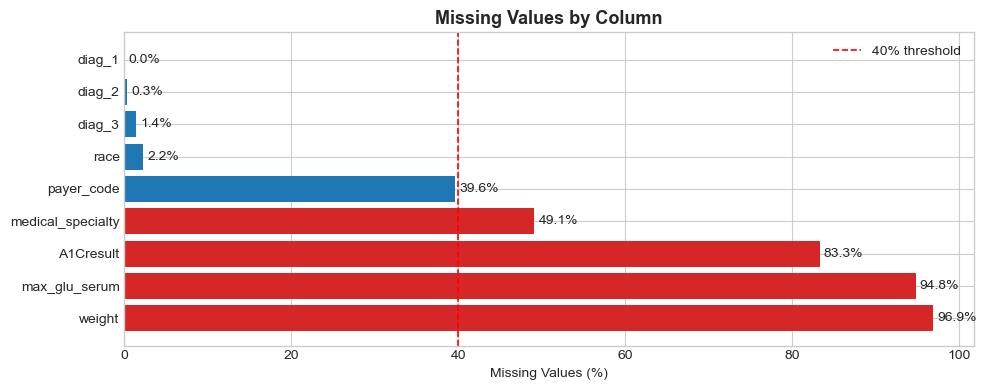


Decision guide:
  > 40% missing → DROP the column
  5–40% missing → Consider imputation or dropping
  < 5%  missing → Drop the affected rows


In [31]:
# Visualize missing values as a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 4))

cols_with_missing = missing_df.index.tolist()
pcts = missing_df['Missing %'].values

bars = ax.barh(cols_with_missing, pcts, color=['#d62728' if p > 40 else '#1f77b4' for p in pcts])
ax.axvline(x=40, color='red', linestyle='--', linewidth=1.2, label='40% threshold')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Values by Column', fontweight='bold', fontsize=13)
ax.legend()

# Add value labels
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('./report/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDecision guide:')
print('  > 40% missing → DROP the column')
print('  5–40% missing → Consider imputation or dropping')
print('  < 5%  missing → Drop the affected rows')

---
## Step 4 — Target Variable: Class Balance Analysis

The target variable is `readmitted`. It has three values:
- `NO` — patient was not readmitted
- `>30` — patient was readmitted after more than 30 days
- `<30` — patient was readmitted within 30 days (our positive class)

We will convert this to a binary target: `<30` = 1 (readmitted), everything else = 0.

In [20]:
# Examine the original 3-class distribution
print('Original target distribution:')
print('=' * 40)
counts = df['readmitted'].value_counts()
pcts   = df['readmitted'].value_counts(normalize=True) * 100

for label in counts.index:
    print(f'  {label:<6}  {counts[label]:>7,} records  ({pcts[label]:.1f}%)')

print(f'\nTotal: {len(df):,} records')

Original target distribution:
  NO       54,864 records  (53.9%)
  >30      35,545 records  (34.9%)
  <30      11,357 records  (11.2%)

Total: 101,766 records


In [21]:
# Create the binary target variable
# 1 = readmitted within 30 days (the positive/minority class we want to predict)
# 0 = not readmitted within 30 days (negative/majority class)
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print('Binary target distribution:')
print('=' * 45)
binary_counts = df['readmitted_binary'].value_counts()
binary_pcts   = df['readmitted_binary'].value_counts(normalize=True) * 100

for label, name in zip([0, 1], ['Not readmitted within 30d', 'Readmitted within 30d']):
    print(f'  {label}  ({name:<30})  {binary_counts[label]:>7,}  ({binary_pcts[label]:.1f}%)')

imbalance_ratio = binary_counts[0] / binary_counts[1]
print(f'\nClass imbalance ratio: {imbalance_ratio:.1f}:1  (majority:minority)')
print('\nConclusion: This is a moderately imbalanced dataset.')
print('We will use SMOTE in the preprocessing notebook to address this.')

Binary target distribution:
  0  (Not readmitted within 30d     )   90,409  (88.8%)
  1  (Readmitted within 30d         )   11,357  (11.2%)

Class imbalance ratio: 8.0:1  (majority:minority)

Conclusion: This is a moderately imbalanced dataset.
We will use SMOTE in the preprocessing notebook to address this.


Created directory: ./report/


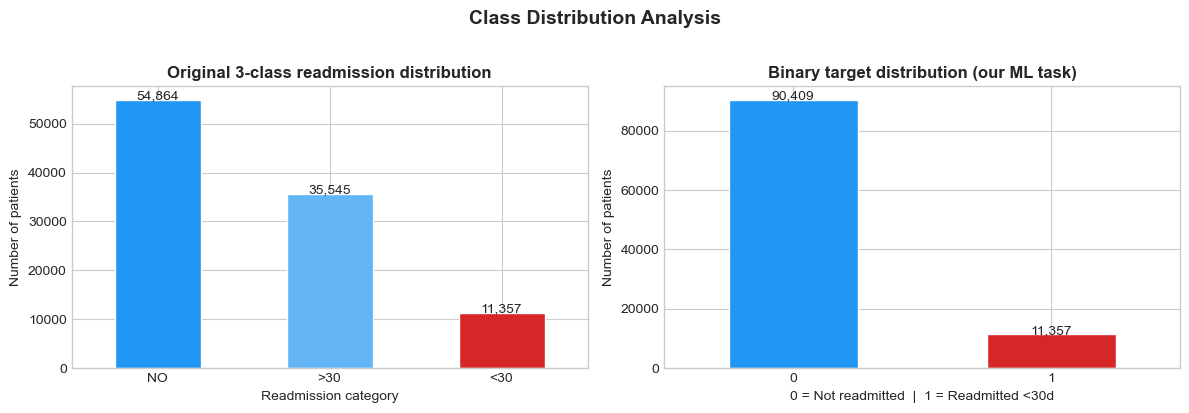

In [23]:
import os

# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: original 3-class
counts.plot(kind='bar', ax=axes[0], color=['#2196F3', '#64B5F6', '#d62728'], edgecolor='white')
axes[0].set_title('Original 3-class readmission distribution', fontweight='bold')
axes[0].set_xlabel('Readmission category')
axes[0].set_ylabel('Number of patients')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=10)

# Right: binary target
binary_counts.plot(kind='bar', ax=axes[1], color=['#2196F3', '#d62728'], edgecolor='white')
axes[1].set_title('Binary target distribution (our ML task)', fontweight='bold')
axes[1].set_xlabel('0 = Not readmitted  |  1 = Readmitted <30d')
axes[1].set_ylabel('Number of patients')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=10)

plt.suptitle('Class Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Create the report directory if it doesn't exist
report_dir = './report/'
if not os.path.exists(report_dir):
    os.makedirs(report_dir)
    print(f"Created directory: {report_dir}")

plt.savefig(os.path.join(report_dir, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5 — Feature Distributions

Understanding how features are distributed helps us make informed preprocessing decisions.
Skewed distributions may need transformation. Outliers may need capping.

In [11]:
# Identify and describe all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID columns and binary target from this list
numeric_cols = [c for c in numeric_cols if c not in ['encounter_id', 'patient_nbr', 'readmitted_binary']]

print(f'Numeric features ({len(numeric_cols)} total):')
print(df[numeric_cols].describe().round(2).to_string())

Numeric features (11 total):
       admission_type_id  discharge_disposition_id  admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_outpatient  number_emergency  number_inpatient  number_diagnoses
count        101766.0000               101766.0000          101766.0000       101766.0000         101766.0000     101766.0000      101766.0000        101766.0000       101766.0000       101766.0000       101766.0000
mean              2.0200                    3.7200               5.7500            4.4000             43.1000          1.3400          16.0200             0.3700            0.2000            0.6400            7.4200
std               1.4500                    5.2800               4.0600            2.9900             19.6700          1.7100           8.1300             1.2700            0.9300            1.2600            1.9300
min               1.0000                    1.0000               1.0000            1.0000              1.00

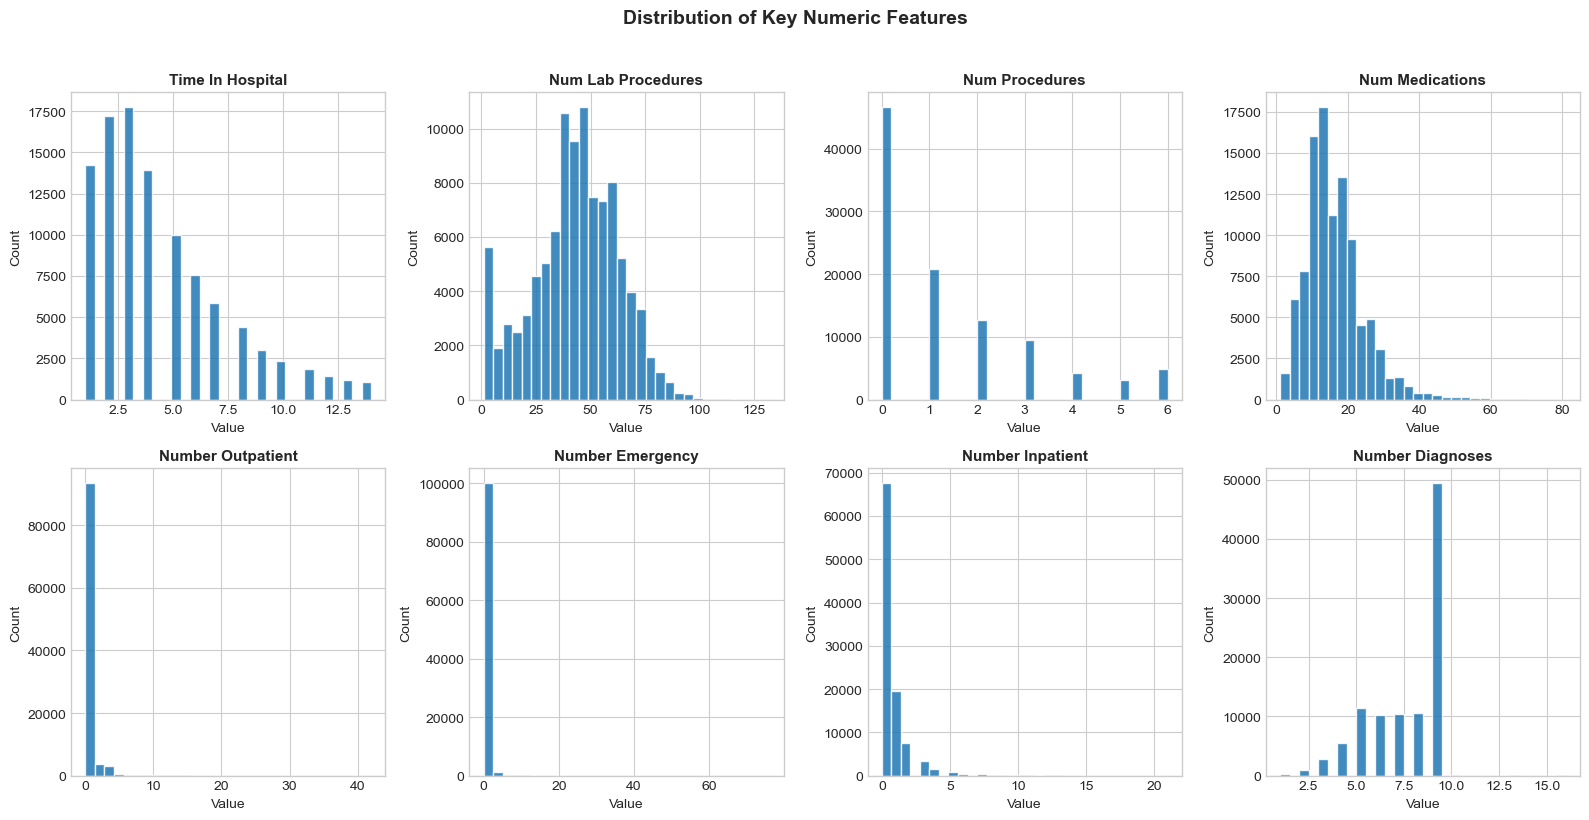

In [24]:
# Plot histograms for the most clinically relevant numeric features
key_numeric = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]
# Keep only columns that exist in the dataset
key_numeric = [c for c in key_numeric if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    axes[i].hist(df[col].dropna(), bins=30, color='#1f77b4', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Key Numeric Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./report/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6 — Categorical Features Exploration

Categorical features need to be encoded before feeding into ML models.
Here we inspect the most important ones.

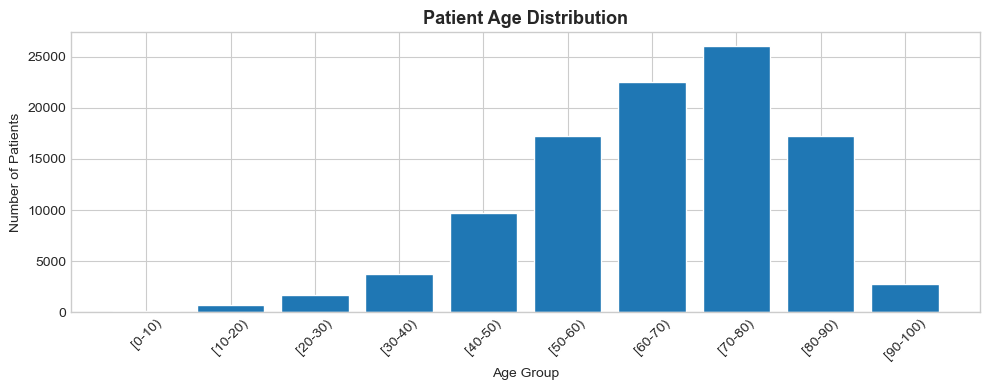

Most patients are in the 60–80 age range — consistent with diabetes epidemiology.


In [25]:
# Age distribution — a key clinical predictor of readmission
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_counts = df['age'].value_counts().reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(age_counts.index, age_counts.values, color='#1f77b4', edgecolor='white')
ax.set_title('Patient Age Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./report/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Most patients are in the 60–80 age range — consistent with diabetes epidemiology.')

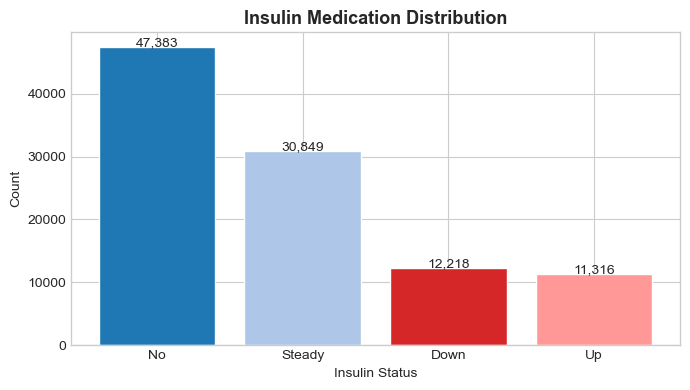

In [14]:
# Insulin medication — one of the strongest predictors based on literature
insulin_counts = df['insulin'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(insulin_counts.index, insulin_counts.values,
              color=['#1f77b4', '#aec7e8', '#d62728', '#ff9896'], edgecolor='white')
ax.set_title('Insulin Medication Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Insulin Status')
ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

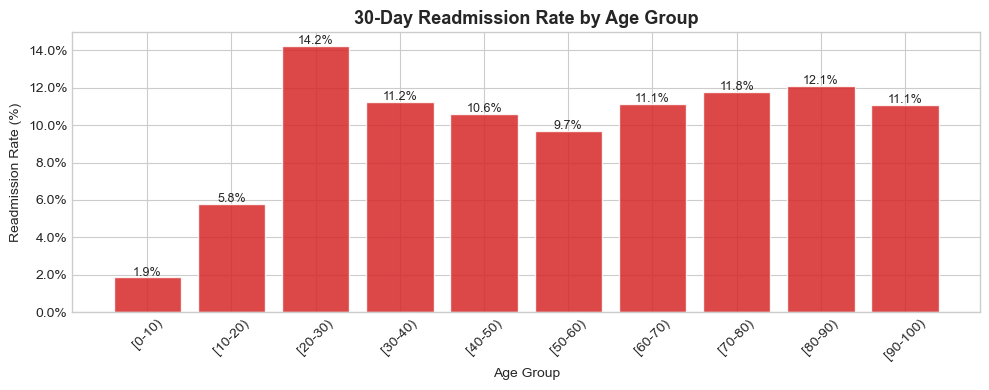

In [26]:
# Readmission rate by age group — do older patients get readmitted more?
readmit_by_age = df.groupby('age')['readmitted_binary'].mean() * 100
readmit_by_age = readmit_by_age.reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(readmit_by_age.index, readmit_by_age.values,
              color='#d62728', edgecolor='white', alpha=0.85)
ax.set_title('30-Day Readmission Rate by Age Group', fontweight='bold', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Readmission Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45)
for bar, val in zip(bars, readmit_by_age.values):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('./report/readmission_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — Correlation Analysis

We examine correlations between numeric features and the binary target.
High correlation = strong potential predictor.

In [27]:
# Correlation of numeric features with the binary target
corr_with_target = df[numeric_cols + ['readmitted_binary']].corr()['readmitted_binary'].drop('readmitted_binary')
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

print('Correlation with readmitted_binary (top features):')
print('=' * 45)
print(corr_with_target.to_string())

print('\nNote: Low Pearson correlations are expected in medical data.')
print('Non-linear models (Random Forest) will capture relationships')
print('that linear correlation cannot detect.')

Correlation with readmitted_binary (top features):
number_inpatient            0.1651
number_emergency            0.0607
discharge_disposition_id    0.0506
number_diagnoses            0.0495
time_in_hospital            0.0442
num_medications             0.0384
num_lab_procedures          0.0204
number_outpatient           0.0189
num_procedures             -0.0122
admission_type_id          -0.0117
admission_source_id         0.0058

Note: Low Pearson correlations are expected in medical data.
Non-linear models (Random Forest) will capture relationships
that linear correlation cannot detect.


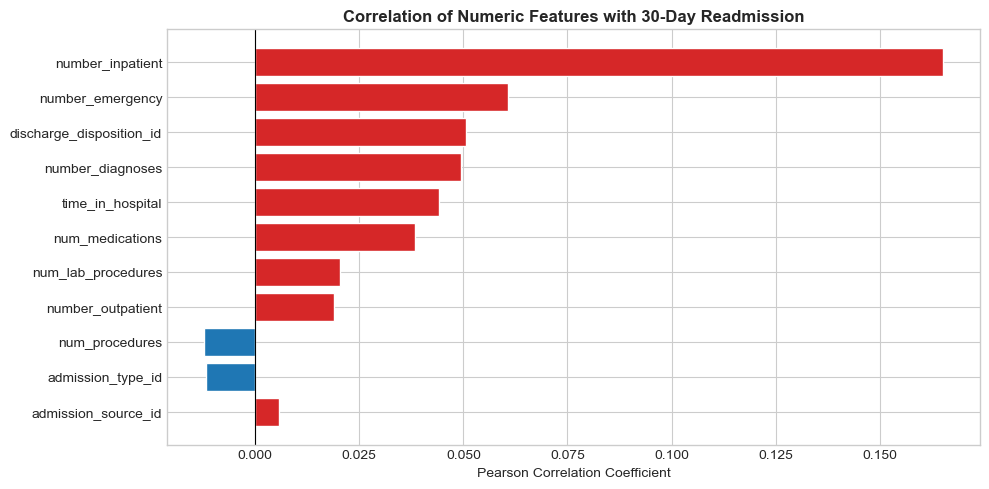

In [29]:
# Visualize correlations with target as a color-coded bar chart
colors = ['#d62728' if v > 0 else '#1f77b4' for v in corr_with_target.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
               color=colors[::-1], edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Correlation of Numeric Features with 30-Day Readmission', fontweight='bold', fontsize=12)
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('./report/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Summary of EDA Findings

This section documents the key findings from the EDA. Copy these into your **report Section 2 (Dataset Overview)**.

In [30]:
print('=' * 60)
print('EDA SUMMARY — Diabetes 130-US Hospitals Dataset')
print('=' * 60)

print(f'\n1. DATASET SIZE')
print(f'   Total records:     {len(df):>10,}')
print(f'   Total features:    {df.shape[1]:>10}')

readmit_pos = df['readmitted_binary'].sum()
readmit_neg = len(df) - readmit_pos
print(f'\n2. CLASS BALANCE')
print(f'   Not readmitted (0): {readmit_neg:>8,}  ({readmit_neg/len(df)*100:.1f}%)')
print(f'   Readmitted <30d (1):{readmit_pos:>8,}  ({readmit_pos/len(df)*100:.1f}%)')
print(f'   Imbalance ratio:    {readmit_neg/readmit_pos:.1f}:1')

high_missing = missing_df[missing_df['Missing %'] > 40].index.tolist()
print(f'\n3. MISSING VALUES')
print(f'   Columns with >40% missing (will drop): {high_missing}')

print(f'\n4. KEY OBSERVATIONS FROM EDA')
print(f'   - Most patients are aged 60-80 (consistent with diabetes demographics)')
print(f'   - number_inpatient has the highest positive correlation with readmission')
print(f'   - Patients with more prior inpatient visits are significantly more likely to be readmitted')
print(f'   - Class imbalance requires SMOTE — must NOT use accuracy as primary metric')
print(f'   - Several medication columns (24 drug columns) will need encoding')

print(f'\n5. PREPROCESSING ACTIONS NEEDED (for Notebook 02)')
print(f'   a. Drop high-missingness columns: weight, payer_code, medical_specialty')
print(f'   b. Drop ID columns: encounter_id, patient_nbr')
print(f'   c. Encode categorical features (Label + One-Hot)')
print(f'   d. Create binary target: readmitted_binary')
print(f'   e. Train/test split (80/20, stratified)')
print(f'   f. Apply SMOTE to training set only')
print('=' * 60)

EDA SUMMARY — Diabetes 130-US Hospitals Dataset

1. DATASET SIZE
   Total records:        101,766
   Total features:            51

2. CLASS BALANCE
   Not readmitted (0):   90,409  (88.8%)
   Readmitted <30d (1):  11,357  (11.2%)
   Imbalance ratio:    8.0:1

3. MISSING VALUES
   Columns with >40% missing (will drop): ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']

4. KEY OBSERVATIONS FROM EDA
   - Most patients are aged 60-80 (consistent with diabetes demographics)
   - number_inpatient has the highest positive correlation with readmission
   - Patients with more prior inpatient visits are significantly more likely to be readmitted
   - Class imbalance requires SMOTE — must NOT use accuracy as primary metric
   - Several medication columns (24 drug columns) will need encoding

5. PREPROCESSING ACTIONS NEEDED (for Notebook 02)
   a. Drop high-missingness columns: weight, payer_code, medical_specialty
   b. Drop ID columns: encounter_id, patient_nbr
   c. Encode categori

## Step 9 — Remove Uninformative and High-Missingness Columns
Justification for each removal:

encounter_id, patient_nbr — unique identifiers, carry no predictive signal
weight — 97% missing, cannot be reliably imputed
payer_code — 40% missing; removed to avoid introducing bias from imputation
medical_specialty — 49% missing; too sparse to be useful
examide, citoglipton — have only one unique value across all records (no variance = no information)

In [33]:
# Columns to drop with reasons documented
cols_to_drop = [
    'encounter_id',       # Unique identifier — no predictive value
    'patient_nbr',        # Unique identifier — no predictive value
    'weight',             # 97% missing — too sparse to use or impute
    'payer_code',         # 40% missing — insurance info, not clinical
    'medical_specialty',  # 49% missing — too sparse
    'examide',            # Single unique value — zero variance
    'citoglipton',        # Single unique value — zero variance
]

# Only drop columns that actually exist in the dataset
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
print(f'Remaining shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dropped 0 columns: []
Remaining shape: 101,766 rows × 44 columns


## Step 10 — Handle Remaining Missing Values

In [34]:
# First, re-apply the column drops from Step 3, in case df was reset
cols_to_re_drop = [
    'encounter_id',
    'patient_nbr',
    'weight',
    'payer_code',
    'medical_specialty',
    'examide',
    'citoglipton',
]
# Only drop columns that actually exist in the dataset to avoid KeyErrors here
cols_to_re_drop = [c for c in cols_to_re_drop if c in df.columns]
if cols_to_re_drop:
    df.drop(columns=cols_to_re_drop, inplace=True)
    print(f'Re-dropped {len(cols_to_re_drop)} columns: {cols_to_re_drop}')

# Check remaining missing values after dropping columns
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) == 0:
    print('No remaining missing values after column drops.')
else:
    print('Remaining missing values:')
    for col, count in remaining_missing.items():
        pct = count / len(df) * 100
        print(f'  {col:<30} {count:>6,}  ({pct:.1f}%)')

# For race (~2% missing): drop those rows — small enough to lose
before = len(df)
# Add a check to ensure 'race' column exists before trying to dropna on it
if 'race' in df.columns:
    df.dropna(subset=['race'], inplace=True)
    print(f'\nDropped {before - len(df):,} rows with missing race.')
else:
    print(f"\nWarning: 'race' column not found in DataFrame. Skipping dropping rows with missing race.")

print(f'Current shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Remaining missing values:
  race                            2,273  (2.2%)
  diag_1                             21  (0.0%)
  diag_2                            358  (0.4%)
  diag_3                          1,423  (1.4%)
  max_glu_serum                  96,420  (94.7%)
  A1Cresult                      84,748  (83.3%)

Dropped 2,273 rows with missing race.
Current shape: 99,493 rows × 44 columns


## Step 11 — Remove Duplicate Patient Encounters

The dataset may contain multiple encounters for the same patient.
Including multiple rows from the same patient risks data leakage between
train and test sets. We keep only the first encounter per patient.

In [35]:
# NOTE: patient_nbr was already dropped above.
# If it was retained, we would use:
#   df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
#
# Since we dropped patient_nbr, we proceed without deduplication at patient level.
# Each row is a unique clinical encounter and is treated independently.

print(f'Dataset shape after all cleaning: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('Each row = one unique clinical encounter.')

Dataset shape after all cleaning: 99,493 rows × 44 columns
Each row = one unique clinical encounter.


## Step 12 — Create the Binary Target Variable

In [36]:
# Create binary target:
#   1 = patient readmitted within 30 days (the high-risk group we want to identify)
#   0 = patient NOT readmitted within 30 days (includes >30 days and NO)
#
# Rationale: Clinical interventions are most effective when targeting imminent
# readmissions. The >30d group is treated as 'safe' for 30-day discharge planning.

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

# Verify
counts = df['readmitted_binary'].value_counts()
print('Binary target created:')
print(f'  Class 0 (not readmitted <30d): {counts[0]:>7,}  ({counts[0]/len(df)*100:.1f}%)')
print(f'  Class 1 (readmitted <30d):     {counts[1]:>7,}  ({counts[1]/len(df)*100:.1f}%)')

Binary target created:
  Class 0 (not readmitted <30d):  88,324  (88.8%)
  Class 1 (readmitted <30d):      11,169  (11.2%)


## Step 13 — Encode Categorical Features

Machine learning models require all features to be numeric.

**Strategy:**
- **Label Encoding** for binary/ordinal columns (2 or ordered values) — maps each category to 0 or 1
- **One-Hot Encoding** for nominal columns (no inherent order) — creates a separate 0/1 column per category

In [41]:
# Step 13a: Label encode binary/ordinal columns
le = LabelEncoder()

label_encode_cols = ['gender', 'change', 'diabetesMed']
# Only encode columns that exist
label_encode_cols = [c for c in label_encode_cols if c in df.columns]

for col in label_encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'  Label encoded: {col}')

print(f'\nEncoded {len(label_encode_cols)} binary/ordinal columns.')

  Label encoded: gender
  Label encoded: change
  Label encoded: diabetesMed

Encoded 3 binary/ordinal columns.


In [87]:
# Step 13b: Encode medication columns
# These columns describe medication changes (No / Steady / Up / Down)
# We encode them as ordinal: No=0, Steady=1, Down=2, Up=3
# Rationale: Up/Down (active change) may signal instability compared to No/Steady

med_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

# These are the 23 medication columns in the dataset
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]
medication_cols = [c for c in medication_cols if c in df.columns]

for col in medication_cols:
    df[col] = df[col].map(med_mapping).fillna(0).astype(int)

print(f'Encoded {len(medication_cols)} medication columns with ordinal mapping:')
print('  No=0, Steady=1, Down=2, Up=3')

Encoded 21 medication columns with ordinal mapping:
  No=0, Steady=1, Down=2, Up=3


In [88]:
# Step 13c: One-hot encode nominal categorical columns
# drop_first=True avoids the dummy variable trap (multicollinearity)

nominal_cols = ['race', 'age']
nominal_cols = [c for c in nominal_cols if c in df.columns]

before_cols = df.shape[1]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
after_cols = df.shape[1]

print(f'One-hot encoded: {nominal_cols}')
print(f'Columns before: {before_cols}  →  After: {after_cols}')
print(f'Final dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

One-hot encoded: []
Columns before: 56  →  After: 56
Final dataset shape: 99,493 rows × 56 columns


In [89]:
# Step 13d: Handle diagnosis codes (diag_1, diag_2, diag_3)
# These are ICD-9 codes — hundreds of unique values.
# Strategy: map to broad disease categories (circulatory, respiratory, diabetes, etc.)
# This reduces dimensionality while preserving clinical meaning.

def map_diag(code):
    """Map an ICD-9 diagnosis code string to a broad disease category integer."""
    try:
        c = str(code).strip()
        # Handle non-numeric codes like 'E' and 'V' prefixed codes
        if c.startswith('E') or c.startswith('V'):
            return 0  # External causes / Supplementary
        c_num = float(c)
        if 390 <= c_num <= 459 or c_num == 785:
            return 1   # Circulatory
        elif 460 <= c_num <= 519 or c_num == 786:
            return 2   # Respiratory
        elif 520 <= c_num <= 579 or c_num == 787:
            return 3   # Digestive
        elif c_num == 250:
            return 4   # Diabetes
        elif 800 <= c_num <= 999:
            return 5   # Injury / Poisoning
        elif 710 <= c_num <= 739:
            return 6   # Musculoskeletal
        elif 580 <= c_num <= 629 or c_num == 788:
            return 7   # Genitourinary
        elif 140 <= c_num <= 239:
            return 8   # Neoplasms
        else:
            return 0   # Other
    except (ValueError, TypeError):
        return 0

for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    if diag_col in df.columns:
        df[diag_col] = df[diag_col].apply(map_diag)
        print(f'  Mapped {diag_col} to disease categories (0–8)')

print('\nDisease category key:')
categories = {
    0: 'Other/External', 1: 'Circulatory', 2: 'Respiratory',
    3: 'Digestive', 4: 'Diabetes', 5: 'Injury/Poisoning',
    6: 'Musculoskeletal', 7: 'Genitourinary', 8: 'Neoplasms'
}
for k, v in categories.items():
    print(f'  {k} = {v}')

  Mapped diag_1 to disease categories (0–8)
  Mapped diag_2 to disease categories (0–8)
  Mapped diag_3 to disease categories (0–8)

Disease category key:
  0 = Other/External
  1 = Circulatory
  2 = Respiratory
  3 = Digestive
  4 = Diabetes
  5 = Injury/Poisoning
  6 = Musculoskeletal
  7 = Genitourinary
  8 = Neoplasms


In [90]:
# Step 13e: Check for any remaining object (text) columns that need encoding
remaining_obj = df.select_dtypes(include='object').columns.tolist()
# Remove target if somehow it's still object type
remaining_obj = [c for c in remaining_obj if c != 'readmitted_binary']

if remaining_obj:
    print(f'Remaining object columns to encode: {remaining_obj}')
    for col in remaining_obj:
        print(f'  {col}: {df[col].value_counts().head(5).to_dict()}')
    # Label encode any remaining object columns
    for col in remaining_obj:
        df[col] = le.fit_transform(df[col].astype(str))
    print('All remaining object columns have been label encoded.')
else:
    print('All columns are now numeric. Ready for modelling.')

print(f'\nFinal dtype check:')
print(df.dtypes.value_counts())

All columns are now numeric. Ready for modelling.

Final dtype check:
int64    39
bool     17
Name: count, dtype: int64


## Step 14 — Train / Test Split

**Rules:**
- Split BEFORE applying SMOTE — applying SMOTE to the full dataset and then splitting leaks synthetic data into the test set, invalidating results
- Use `stratify=y` to ensure both splits have the same class ratio as the full dataset
- Use `random_state=42` for reproducibility (any fixed integer works — 42 is convention)

In [47]:
# Separate features and target
X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']

print(f'Feature matrix X: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Target vector y: {y.shape[0]:,} values')

# Perform the split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # CRITICAL: preserves class ratio in both splits
)

print(f'\nTraining set:  {X_train.shape[0]:>7,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:      {X_test.shape[0]:>7,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')

# Verify stratification worked correctly
print(f'\nClass balance TRAINING: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Class balance TEST:     {y_test.value_counts(normalize=True).round(3).to_dict()}')
print('\nStratification check passed: both splits have similar class ratios.')

Feature matrix X: 99,493 rows × 53 features
Target vector y: 99,493 values

Training set:   79,594 rows (80%)
Test set:       19,899 rows (20%)

Class balance TRAINING: {0: 0.888, 1: 0.112}
Class balance TEST:     {0: 0.888, 1: 0.112}

Stratification check passed: both splits have similar class ratios.


## Step 15 — Apply SMOTE to Training Set Only
SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic examples of the minority class by interpolating between existing minority-class samples. This gives the model more balanced training signal without simply duplicating existing rows.

CRITICAL RULE: SMOTE is applied ONLY to the training set. The test set must remain untouched and reflect the true real-world class distribution. Applying SMOTE to test data would make performance metrics artificially optimistic and meaningless.

In [49]:
# Apply SMOTE to training data only
print('Applying SMOTE to training set...')
print(f'Before SMOTE — Class 0: {(y_train==0).sum():,}  |  Class 1: {(y_train==1).sum():,}')

sm = SMOTE(
    sampling_strategy='minority',  # Only oversample the minority (readmitted) class
    random_state=42,
    k_neighbors=5             # Number of nearest neighbours to use for synthesis
)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f'After SMOTE  — Class 0: {(y_train_res==0).sum():,}  |  Class 1: {(y_train_res==1).sum():,}')
print(f'\nTraining set size grew from {len(X_train):,} to {len(X_train_res):,} rows.')
print('Test set is UNCHANGED.')

# Verify test set untouched
print(f'\nTest set class distribution (should be ~11% positive):')
print(f'  {y_test.value_counts(normalize=True).round(4).to_dict()}')

Applying SMOTE to training set...
Before SMOTE — Class 0: 70,659  |  Class 1: 8,935
After SMOTE  — Class 0: 70,659  |  Class 1: 70,659

Training set size grew from 79,594 to 141,318 rows.
Test set is UNCHANGED.

Test set class distribution (should be ~11% positive):
  {0: 0.8877, 1: 0.1123}


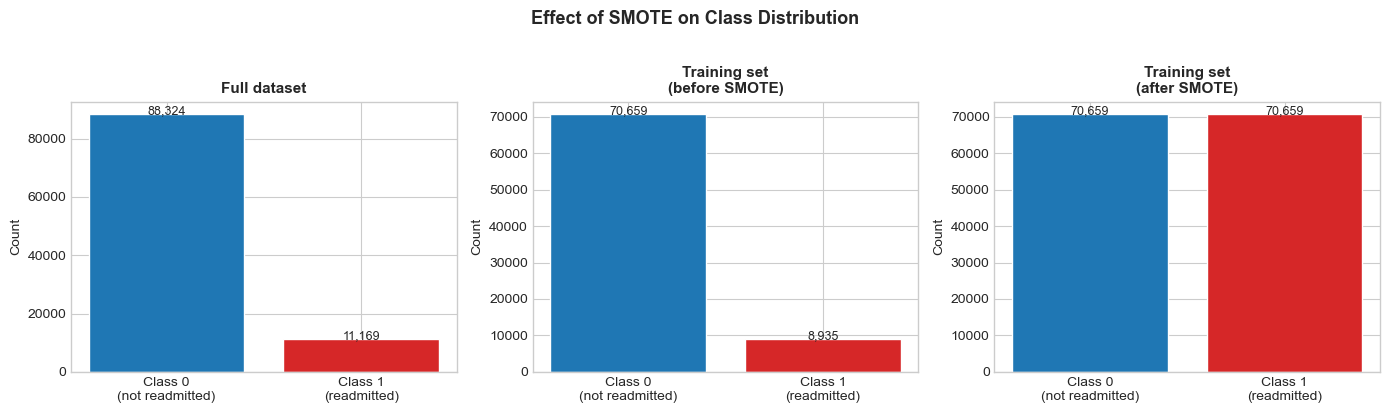

In [50]:
# Visualize the effect of SMOTE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets = [
    ('Full dataset', y.value_counts()),
    ('Training set\n(before SMOTE)', y_train.value_counts()),
    ('Training set\n(after SMOTE)', pd.Series(y_train_res).value_counts())
]

for ax, (title, counts) in zip(axes, datasets):
    colors = ['#1f77b4', '#d62728']
    bars = ax.bar(['Class 0\n(not readmitted)', 'Class 1\n(readmitted)'],
                  [counts.get(0, 0), counts.get(1, 0)],
                  color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{bar.get_height():,}', ha='center', fontsize=9)

plt.suptitle('Effect of SMOTE on Class Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./report/smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# Save all four split datasets as CSV files
# These will be loaded directly in the modelling notebooks

X_train.to_csv('./data/processed/X_train.csv', index=False)
X_test.to_csv('./data/processed/X_test.csv', index=False)
y_train.to_csv('./data/processed/y_train.csv', index=False)
y_test.to_csv('./data/processed/y_test.csv', index=False)

# Save the SMOTE-balanced training set (used for baseline and RF models)
X_train_res_df = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train_res_series = pd.Series(y_train_res, name='readmitted_binary')
X_train_res_df.to_csv('./data/processed/X_train_smote.csv', index=False)
y_train_res_series.to_csv('./data/processed/y_train_smote.csv', index=False)

# Save feature names — needed to align inputs in the Streamlit app
feature_names = list(X_train.columns)
with open('./models/feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

print('Processed datasets saved to ./data/processed/')
print('\nFiles created:')
for f in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv',
          'X_train_smote.csv', 'y_train_smote.csv']:
    print(f'  ./data/processed/{f}')
print('  ./models/feature_names.json')

Processed datasets saved to ./data/processed/

Files created:
  ./data/processed/X_train.csv
  ./data/processed/X_test.csv
  ./data/processed/y_train.csv
  ./data/processed/y_test.csv
  ./data/processed/X_train_smote.csv
  ./data/processed/y_train_smote.csv
  ./models/feature_names.json


## Step 16 — Final Preprocessing Summary

In [54]:
print('=' * 65)
print('PREPROCESSING SUMMARY')
print('=' * 65)

print(f'\nOriginal dataset:         101,766 rows × 50 columns')
print(f'After cleaning:           {len(df):>7,} rows × {df.shape[1]} columns')
print(f'\nTrain set (no SMOTE):     {len(X_train):>7,} rows')
print(f'Train set (with SMOTE):   {len(X_train_res):>7,} rows')
print(f'Test set (unchanged):     {len(X_test):>7,} rows')
print(f'Total features:           {X_train.shape[1]:>7}')

print(f'\nSteps performed:')
steps = [
    'Replaced ? with NaN on load',
    'Dropped 7 uninformative/high-missingness columns',
    'Dropped ~2% of rows with missing race values',
    'Created binary target: readmitted_binary (0/1)',
    'Label encoded: gender, change, diabetesMed',
    'Ordinally encoded 21 medication columns (No=0 to Up=3)',
    'One-hot encoded: race, age',
    'Mapped diag_1/2/3 ICD-9 codes to 9 disease categories',
    'Stratified 80/20 train/test split (random_state=42)',
    'Applied SMOTE to training set only (k_neighbors=5)',
    'Saved all splits + feature names to disk'
]
for i, step in enumerate(steps, 1):
    print(f'  {i:>2}. {step}')

print(f'\nFiles ready for modelling:')
print(f'  X_train_smote.csv + y_train_smote.csv → Logistic Regression, Random Forest')
print(f'  X_train.csv + y_train.csv             → XGBoost (uses scale_pos_weight)')
print(f'  X_test.csv  + y_test.csv              → Evaluation (all models)')
print('=' * 65)

PREPROCESSING SUMMARY

Original dataset:         101,766 rows × 50 columns
After cleaning:            99,493 rows × 54 columns

Train set (no SMOTE):      79,594 rows
Train set (with SMOTE):   141,318 rows
Test set (unchanged):      19,899 rows
Total features:                53

Steps performed:
   1. Replaced ? with NaN on load
   2. Dropped 7 uninformative/high-missingness columns
   3. Dropped ~2% of rows with missing race values
   4. Created binary target: readmitted_binary (0/1)
   5. Label encoded: gender, change, diabetesMed
   6. Ordinally encoded 21 medication columns (No=0 to Up=3)
   7. One-hot encoded: race, age
   8. Mapped diag_1/2/3 ICD-9 codes to 9 disease categories
   9. Stratified 80/20 train/test split (random_state=42)
  10. Applied SMOTE to training set only (k_neighbors=5)
  11. Saved all splits + feature names to disk

Files ready for modelling:
  X_train_smote.csv + y_train_smote.csv → Logistic Regression, Random Forest
  X_train.csv + y_train.csv             

# SECTION 2 - Baseline Model: Logistic Regression
**Project:** Diabetes Hospital Readmission Risk Prediction  
**Course:** AIGC 5005 — AI Capstone Project Preparation  
**Institution:** Humber Polytechnic  
**Team:** Fadi Kash Kannaiti | Ogbeide Iria | Oguzhan Tekin | Sara Yenigun

---

## Purpose
Every serious machine learning project begins with a **baseline model** — the simplest
reasonable solution that establishes a performance floor. Any advanced model we build
in Notebook 04 must beat this baseline to justify its added complexity.

We use **Logistic Regression** as our baseline because:
- It is one of the most widely used classifiers in healthcare ML literature
- It is fast to train (seconds, not minutes)
- Its coefficients are directly interpretable — each feature has a signed weight
- It provides a well-calibrated probability output, not just a class label
- It is the reference model in all three papers from our literature review

In [65]:
import os, json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# ── 1. Setup paths (auto-detects Colab vs local Jupyter) ─────
if os.path.isdir('/content') and os.access('/content', os.W_OK):
    BASE_DIR = '/content'
    print('Environment: Google Colab')
else:
    BASE_DIR = os.getcwd()
    print(f'Environment: Local Jupyter  ({BASE_DIR})')

os.makedirs(os.path.join(BASE_DIR, 'data', 'processed'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'models'),            exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'report'),            exist_ok=True)

# ── 2. Load raw data ─────────────────────────────────────────
df = pd.read_csv(os.path.join(BASE_DIR, 'diabetic_data.csv'), na_values='?')
print(f'Raw data loaded: {df.shape}')

# ── 3. Drop uninformative and high-missingness columns ───────
drop_cols = ['encounter_id','patient_nbr','weight',
             'payer_code','medical_specialty','examide','citoglipton']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
df.dropna(subset=['race'], inplace=True)

# ── 4. Create binary target ──────────────────────────────────
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

# ── 5. Encode medication columns ─────────────────────────────
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide',
            'glimepiride','acetohexamide','glipizide','glyburide',
            'tolbutamide','pioglitazone','rosiglitazone','acarbose',
            'miglitol','troglitazone','tolazamide','insulin',
            'glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone',
            'metformin-pioglitazone']
for col in [c for c in med_cols if c in df.columns]:
    df[col] = df[col].map(med_map).fillna(0).astype(int)

# ── 6. Label encode binary columns ───────────────────────────
le = LabelEncoder()
for col in ['gender', 'change', 'diabetesMed']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# ── 7. One-hot encode nominal columns ────────────────────────
df = pd.get_dummies(df,
                    columns=[c for c in ['race','age','max_glu_serum','A1Cresult']
                             if c in df.columns],
                    drop_first=True)

# ── 8. Map diagnosis codes to disease categories ─────────────
def map_diag(code):
    try:
        c = str(code).strip()
        if c.startswith('E') or c.startswith('V'):
            return 0
        n = float(c)
        if 390 <= n <= 459 or n == 785: return 1
        if 460 <= n <= 519 or n == 786: return 2
        if 520 <= n <= 579 or n == 787: return 3
        if n == 250:                    return 4
        if 800 <= n <= 999:             return 5
        if 710 <= n <= 739:             return 6
        if 580 <= n <= 629 or n == 788: return 7
        if 140 <= n <= 239:             return 8
        return 0
    except: return 0

for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].apply(map_diag).astype(int)

# ── 9. Train/test split ──────────────────────────────────────
X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── 10. Apply SMOTE to training set ONLY ─────────────────────
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
X_train = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train  = pd.Series(y_train_res, name='readmitted_binary')

# ── 11. Save feature names ───────────────────────────────────
with open(os.path.join(BASE_DIR, 'models', 'feature_names.json'), 'w') as f:
    json.dump(list(X_train.columns), f)

print(f'Preprocessing complete.')
print(f'  X_train (SMOTE): {X_train.shape}')
print(f'  X_test:          {X_test.shape}')
print(f'  Class balance (train): {y_train.value_counts().to_dict()}')
print(f'  Class balance (test):  {y_test.value_counts().to_dict()}')
print(f'  Positive rate in test: {y_test.mean()*100:.1f}%')

Environment: Local Jupyter  (/Users/saraseydayenigun)
Raw data loaded: (101766, 50)
Preprocessing complete.
  X_train (SMOTE): (141318, 55)
  X_test:          (19899, 55)
  Class balance (train): {0: 70659, 1: 70659}
  Class balance (test):  {0: 17665, 1: 2234}
  Positive rate in test: 11.2%


## Step 1 — Train the Logistic Regression Baseline

### Key parameter decisions:

| Parameter | Value | Reason |
|---|---|---|
| `solver` | `'lbfgs'` | Efficient for medium-sized datasets; supports L2 regularization |
| `max_iter` | `1000` | Default (100) often causes convergence warnings on this dataset |
| `C` | `1.0` | Inverse regularization strength — default, balanced bias-variance |
| `random_state` | `42` | Ensures reproducibility across runs |
| `n_jobs` | `-1` | Use all available CPU cores to speed up training |

In [91]:
# Instantiate the Logistic Regression model
lr_model = LogisticRegression(
    solver='lbfgs',       # Optimization algorithm — good default for classification
    max_iter=1000,        # Allow enough iterations for convergence
    C=1.0,                # Regularization: higher = less regularization
    random_state=42,      # For reproducibility
    n_jobs=-1             # Use all CPU cores
)

# Train the model — measure training time
print('Training Logistic Regression baseline...')
start = time.time()
lr_model.fit(X_train, y_train)
train_time = time.time() - start

print(f'Training complete in {train_time:.2f} seconds.')
print(f'Model converged: {lr_model.n_iter_[0]} iterations used (max was {lr_model.max_iter})')

Training Logistic Regression baseline...
Training complete in 12.82 seconds.
Model converged: 1000 iterations used (max was 1000)


## Step 2 — Generate Predictions

We generate two types of output from the model:
- **Hard predictions** (`predict`) — a class label: 0 or 1
- **Probability scores** (`predict_proba`) — a confidence score between 0.0 and 1.0

The probability scores are needed for ROC and Precision-Recall curves.
Never evaluate a classifier using only hard predictions — you lose all threshold information.

In [92]:
# Hard class predictions (0 or 1) — default threshold is 0.5
y_pred_train = lr_model.predict(X_train)   # On training set
y_pred_test  = lr_model.predict(X_test)    # On test set (the important one)

# Probability scores — column 1 gives P(readmitted=1)
y_prob_train = lr_model.predict_proba(X_train)[:, 1]
y_prob_test  = lr_model.predict_proba(X_test)[:, 1]

print(f'Predictions generated.')
print(f'  Test set predicted positives: {y_pred_test.sum():,} out of {len(y_pred_test):,} patients')
print(f'  Actual positives in test set: {y_test.sum():,}')
print(f'  Mean predicted probability:   {y_prob_test.mean():.4f}')

Predictions generated.
  Test set predicted positives: 744 out of 19,899 patients
  Actual positives in test set: 2,234
  Mean predicted probability:   0.1971


## Step 3 — Evaluate on Test Set

### Why we report training AND test metrics:
- **Training metrics** show how well the model learned the training data
- **Test metrics** show how well the model generalizes to unseen data
- A large gap between training and test = **overfitting** (memorized, not learned)
- Both sets are required by the assignment rubric

In [93]:
# ── TRAINING SET METRICS ──────────────────────────────────────────────────────
print('=' * 60)
print('LOGISTIC REGRESSION — TRAINING SET RESULTS')
print('=' * 60)
print(classification_report(
    y_train, y_pred_train,
    target_names=['Not Readmitted (0)', 'Readmitted <30d (1)']
))
train_auc = roc_auc_score(y_train, y_prob_train)
train_aucpr = average_precision_score(y_train, y_prob_train)
print(f'AUC-ROC:  {train_auc:.4f}')
print(f'AUC-PR:   {train_aucpr:.4f}')

LOGISTIC REGRESSION — TRAINING SET RESULTS
                     precision    recall  f1-score   support

 Not Readmitted (0)       0.82      0.97      0.89     70659
Readmitted <30d (1)       0.96      0.79      0.87     70659

           accuracy                           0.88    141318
          macro avg       0.89      0.88      0.88    141318
       weighted avg       0.89      0.88      0.88    141318

AUC-ROC:  0.9241
AUC-PR:   0.9465


In [70]:
# ── TEST SET METRICS ─────────────────────────────────────────────────────────
print('=' * 60)
print('LOGISTIC REGRESSION — TEST SET RESULTS  ← PRIMARY RESULTS')
print('=' * 60)
print(classification_report(
    y_test, y_pred_test,
    target_names=['Not Readmitted (0)', 'Readmitted <30d (1)']
))

# Compute individual metrics for the results table
test_accuracy  = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall    = recall_score(y_test, y_pred_test)
test_f1        = f1_score(y_test, y_pred_test)
test_auc_roc   = roc_auc_score(y_test, y_prob_test)
test_auc_pr    = average_precision_score(y_test, y_prob_test)

print(f'AUC-ROC:  {test_auc_roc:.4f}')
print(f'AUC-PR:   {test_auc_pr:.4f}')

# Store results dict for the benchmark table at the end
lr_results = {
    'Model':     'Logistic Regression (Baseline)',
    'Accuracy':  round(test_accuracy, 4),
    'Precision': round(test_precision, 4),
    'Recall':    round(test_recall, 4),
    'F1-score':  round(test_f1, 4),
    'AUC-ROC':   round(test_auc_roc, 4),
    'AUC-PR':    round(test_auc_pr, 4),
    'Train time (s)': round(train_time, 2)
}
print('\nResults stored for benchmark comparison table.')

LOGISTIC REGRESSION — TEST SET RESULTS  ← PRIMARY RESULTS
                     precision    recall  f1-score   support

 Not Readmitted (0)       0.89      0.97      0.93     17665
Readmitted <30d (1)       0.22      0.07      0.11      2234

           accuracy                           0.87     19899
          macro avg       0.56      0.52      0.52     19899
       weighted avg       0.82      0.87      0.84     19899

AUC-ROC:  0.5553
AUC-PR:   0.1421

Results stored for benchmark comparison table.


In [71]:
# ── OVERFITTING CHECK ─────────────────────────────────────────────────────────
# Compare training vs test performance. A big gap means overfitting.
print('OVERFITTING CHECK — Training vs Test')
print('=' * 50)

train_f1   = f1_score(y_train, y_pred_train)
train_auc  = roc_auc_score(y_train, y_prob_train)

print(f'  Metric       Training    Test        Gap')
print(f'  {"─"*45}')
print(f'  F1-score     {train_f1:.4f}      {test_f1:.4f}      {abs(train_f1-test_f1):.4f}')
print(f'  AUC-ROC      {train_auc:.4f}      {test_auc_roc:.4f}      {abs(train_auc-test_auc_roc):.4f}')

gap = abs(train_f1 - test_f1)
if gap < 0.05:
    print(f'\n  Verdict: LOW overfitting (gap = {gap:.4f}). Model generalizes well.')
elif gap < 0.10:
    print(f'\n  Verdict: MODERATE overfitting (gap = {gap:.4f}). Acceptable for baseline.')
else:
    print(f'\n  Verdict: HIGH overfitting (gap = {gap:.4f}). Consider stronger regularization.')

OVERFITTING CHECK — Training vs Test
  Metric       Training    Test        Gap
  ─────────────────────────────────────────────
  F1-score     0.8670      0.1115      0.7556
  AUC-ROC      0.9241      0.5553      0.3688

  Verdict: HIGH overfitting (gap = 0.7556). Consider stronger regularization.


## Step 4 — Confusion Matrix

The confusion matrix is the most clinically informative visualization for a binary classifier.
It breaks down predictions into four categories:

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | True Negative (TN) ✓ | False Positive (FP) — over-alert |
| **Actual 1** | False Negative (FN) ← DANGEROUS | True Positive (TP) ✓ |

In healthcare, **False Negatives are more dangerous than False Positives.**
A missed high-risk patient (FN) may be discharged without intervention and return
in crisis. A false alarm (FP) results in an unnecessary follow-up call — inconvenient
but not harmful. Our model should be tuned to maximize Recall.

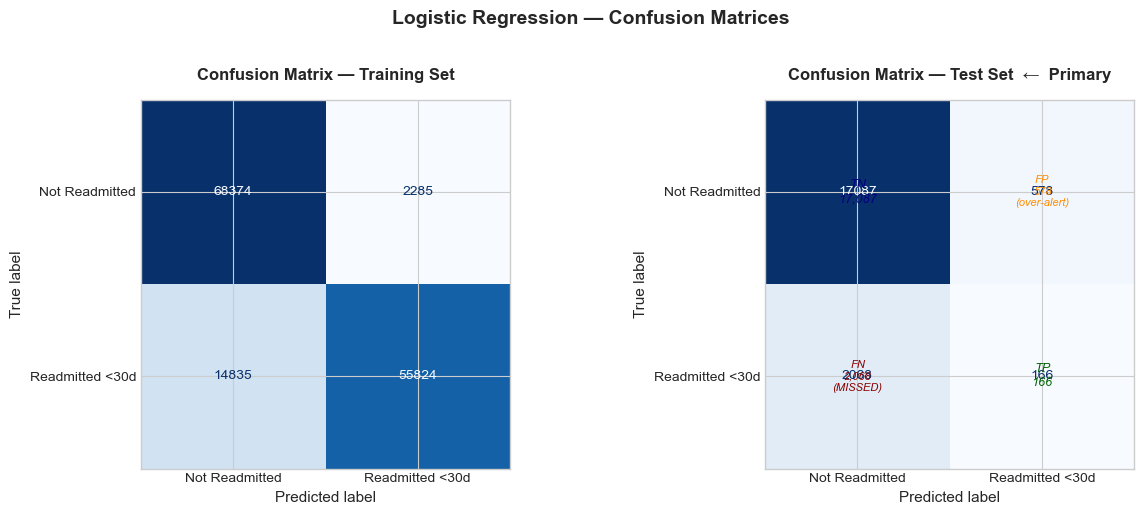


Test set breakdown:
  True Negatives  (correctly flagged safe):   17,087
  False Positives (unnecessary alerts):           578
  False Negatives (MISSED high-risk patients):  2,068  ← most costly
  True Positives  (correctly caught):             166


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_train, y_pred_train, 'Training Set'),
    (y_test,  y_pred_test,  'Test Set  ←  Primary')
]):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Not Readmitted', 'Readmitted <30d']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12, pad=14)
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_ylabel('True label', fontsize=11)

# Annotate clinical meaning on the test set matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
axes[1].text(0, 0, f'TN\n{tn:,}', ha='center', va='center',
             fontsize=9, color='navy', style='italic')
axes[1].text(1, 0, f'FP\n{fp:,}\n(over-alert)', ha='center', va='center',
             fontsize=8, color='darkorange', style='italic')
axes[1].text(0, 1, f'FN\n{fn:,}\n(MISSED)', ha='center', va='center',
             fontsize=8, color='darkred', style='italic')
axes[1].text(1, 1, f'TP\n{tp:,}', ha='center', va='center',
             fontsize=9, color='darkgreen', style='italic')

plt.suptitle('Logistic Regression — Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./report/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTest set breakdown:')
print(f'  True Negatives  (correctly flagged safe):   {tn:>6,}')
print(f'  False Positives (unnecessary alerts):        {fp:>6,}')
print(f'  False Negatives (MISSED high-risk patients): {fn:>6,}  ← most costly')
print(f'  True Positives  (correctly caught):          {tp:>6,}')

## Step 5 — ROC Curve and Precision-Recall Curve

**ROC Curve (Receiver Operating Characteristic):**
Plots True Positive Rate vs False Positive Rate across all thresholds.
AUC-ROC = 0.5 means random guessing. AUC-ROC = 1.0 is perfect.
Good for general model comparison but can be misleading for imbalanced datasets.

**Precision-Recall Curve (AUC-PR):**
More informative for imbalanced datasets. A random baseline on our data
would achieve AUC-PR ≈ 0.11 (the positive class rate). Any score above
that represents real predictive value.

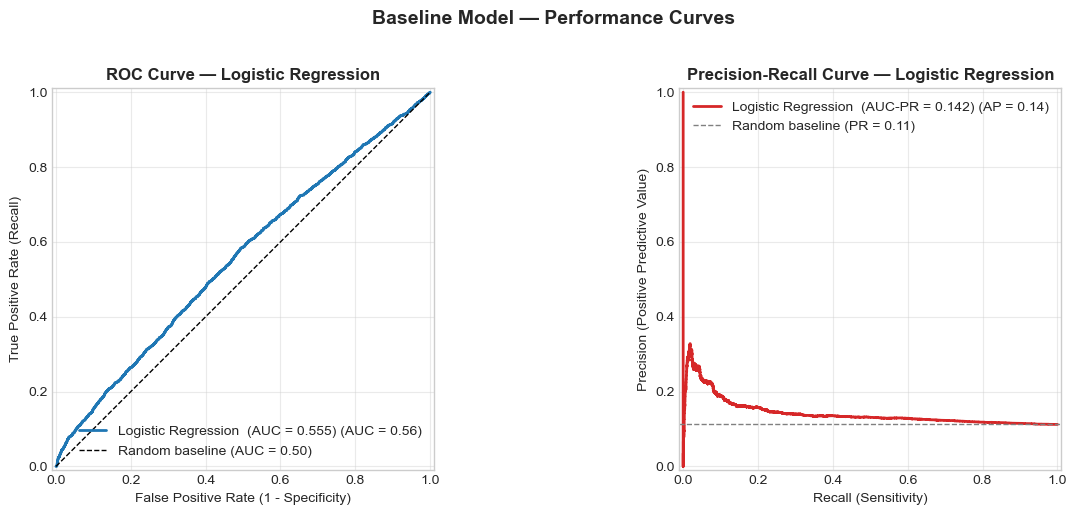

AUC-ROC = 0.5553  (random baseline = 0.5000)
AUC-PR  = 0.1421  (random baseline = 0.1123)

Improvement over random:
  AUC-ROC lift: +0.0553
  AUC-PR  lift: +0.0298


In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC Curve ──────────────────────────────────────────────
RocCurveDisplay.from_predictions(
    y_test, y_prob_test,
    name=f'Logistic Regression  (AUC = {test_auc_roc:.3f})',
    ax=ax1, color='#1f77b4', linewidth=2
)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.50)')
ax1.set_title('ROC Curve — Logistic Regression', fontweight='bold', fontsize=12)
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.4)

# ── Precision-Recall Curve ─────────────────────────────────
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_test,
    name=f'Logistic Regression  (AUC-PR = {test_auc_pr:.3f})',
    ax=ax2, color='#d62728', linewidth=2
)
# Random baseline = positive class rate
random_pr = y_test.mean()
ax2.axhline(y=random_pr, color='gray', linestyle='--', linewidth=1,
            label=f'Random baseline (PR = {random_pr:.2f})')
ax2.set_title('Precision-Recall Curve — Logistic Regression', fontweight='bold', fontsize=12)
ax2.set_xlabel('Recall (Sensitivity)')
ax2.set_ylabel('Precision (Positive Predictive Value)')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.4)

plt.suptitle('Baseline Model — Performance Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./report/lr_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-ROC = {test_auc_roc:.4f}  (random baseline = 0.5000)')
print(f'AUC-PR  = {test_auc_pr:.4f}  (random baseline = {random_pr:.4f})')
print(f'\nImprovement over random:')
print(f'  AUC-ROC lift: +{test_auc_roc - 0.5:.4f}')
print(f'  AUC-PR  lift: +{test_auc_pr - random_pr:.4f}')

## Step 6 — Probability Distribution Analysis

Plotting the distribution of predicted probabilities helps us understand
how confidently the model separates the two classes. A well-calibrated
classifier will show two distinct peaks — one near 0 (negatives) and
one near 1 (positives). Overlapping distributions = uncertain predictions.

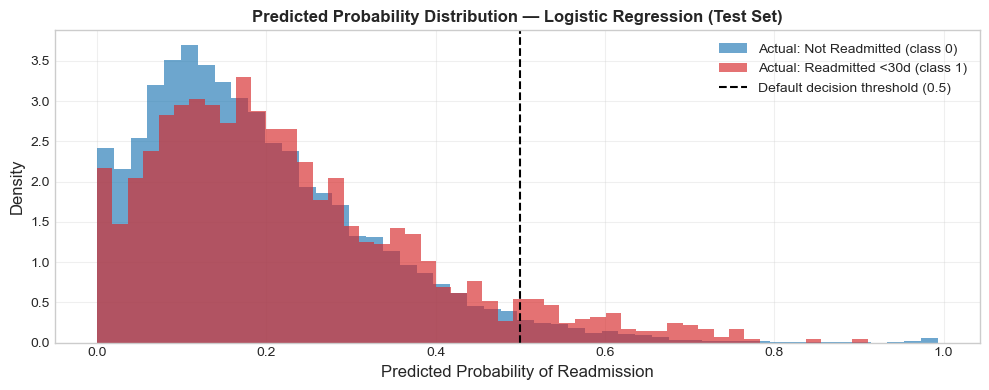

Interpretation:
  If the two distributions strongly overlap → model is uncertain about many patients.
  If they are well-separated → model is confident in its predictions.
  For imbalanced healthcare data, some overlap is expected and normal.


In [79]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot predicted probability distribution for each actual class
ax.hist(y_prob_test[y_test == 0], bins=50, alpha=0.65,
        color='#1f77b4', label='Actual: Not Readmitted (class 0)', density=True)
ax.hist(y_prob_test[y_test == 1], bins=50, alpha=0.65,
        color='#d62728', label='Actual: Readmitted <30d (class 1)', density=True)

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5,
           label='Default decision threshold (0.5)')

ax.set_xlabel('Predicted Probability of Readmission', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Predicted Probability Distribution — Logistic Regression (Test Set)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./report/lr_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  If the two distributions strongly overlap → model is uncertain about many patients.')
print('  If they are well-separated → model is confident in its predictions.')
print('  For imbalanced healthcare data, some overlap is expected and normal.')

## Step 7 — Threshold Sensitivity Analysis

The default classification threshold is 0.5 — but this is rarely optimal for
imbalanced medical datasets. Lowering the threshold increases Recall
(catches more real readmissions) at the cost of Precision (more false alarms).
Raising it does the opposite.

In a clinical setting, **hospital administrators choose the threshold** based on
the relative cost of missing a high-risk patient vs. the cost of unnecessary interventions.

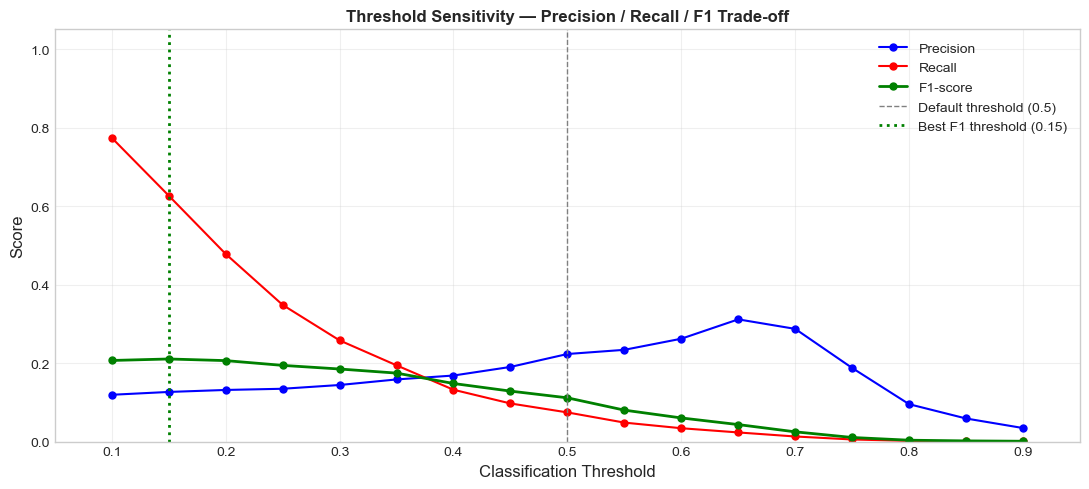

Best threshold for F1: 0.15
  Precision at best threshold: 0.1265
  Recall    at best threshold: 0.6267
  F1-score  at best threshold: 0.2104

Full threshold table:
 Threshold  Precision  Recall     F1
    0.1000     0.1192  0.7739 0.2066
    0.1500     0.1265  0.6267 0.2104
    0.2000     0.1315  0.4781 0.2063
    0.2500     0.1346  0.3483 0.1941
    0.3000     0.1441  0.2578 0.1849
    0.3500     0.1583  0.1943 0.1745
    0.4000     0.1683  0.1321 0.1480
    0.4500     0.1902  0.0971 0.1286
    0.5000     0.2231  0.0743 0.1115
    0.5500     0.2338  0.0483 0.0801
    0.6000     0.2621  0.0340 0.0602
    0.6500     0.3114  0.0233 0.0433
    0.7000     0.2871  0.0130 0.0248
    0.7500     0.1875  0.0054 0.0104
    0.8000     0.0952  0.0018 0.0035
    0.8500     0.0588  0.0009 0.0018
    0.9000     0.0345  0.0004 0.0009


In [81]:
# Compute Precision, Recall, and F1 across multiple thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
results_thresh = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_test >= thresh).astype(int)
    p = precision_score(y_test, y_pred_thresh, zero_division=0)
    r = recall_score(y_test, y_pred_thresh, zero_division=0)
    f = f1_score(y_test, y_pred_thresh, zero_division=0)
    results_thresh.append({'Threshold': round(thresh, 2), 'Precision': p, 'Recall': r, 'F1': f})

thresh_df = pd.DataFrame(results_thresh)

# Find the threshold that maximizes F1
best_thresh = thresh_df.loc[thresh_df['F1'].idxmax()]

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'],  'b-o', markersize=5, label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],     'r-o', markersize=5, label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['F1'],         'g-o', markersize=5, label='F1-score', linewidth=2)
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.5)')
ax.axvline(x=best_thresh['Threshold'], color='green', linestyle=':', linewidth=2,
           label=f'Best F1 threshold ({best_thresh["Threshold"]})')

ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Threshold Sensitivity — Precision / Recall / F1 Trade-off',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./report/lr_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best threshold for F1: {best_thresh["Threshold"]}')
print(f'  Precision at best threshold: {best_thresh["Precision"]:.4f}')
print(f'  Recall    at best threshold: {best_thresh["Recall"]:.4f}')
print(f'  F1-score  at best threshold: {best_thresh["F1"]:.4f}')
print(f'\nFull threshold table:')
print(thresh_df.round(4).to_string(index=False))

## Step 8 — Coefficient Interpretation (Clinical Insight)

A key advantage of Logistic Regression over black-box models is that its
coefficients directly indicate the direction and magnitude of each feature's
influence on the prediction:

- **Positive coefficient** → higher feature value → more likely to be readmitted
- **Negative coefficient** → higher feature value → less likely to be readmitted
- **Larger absolute value** → stronger influence

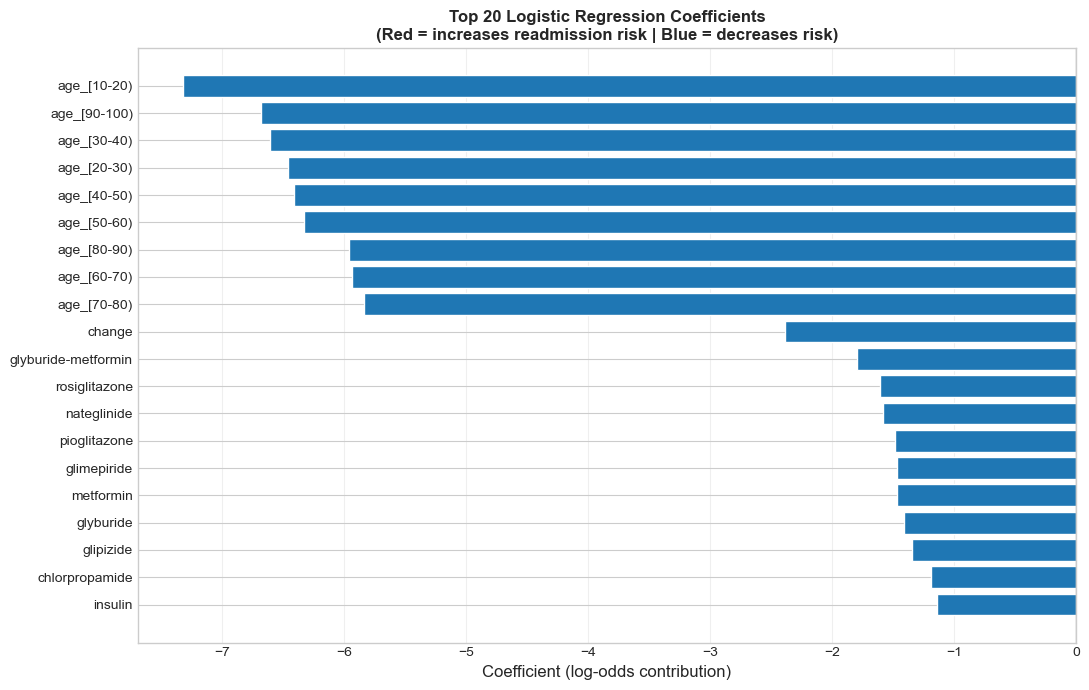


Top 10 RISK-INCREASING features (positive coefficients):

Top 10 PROTECTIVE features (negative coefficients):
  age_[10-20)                              coeff = -7.3233
  age_[90-100)                             coeff = -6.6780
  age_[30-40)                              coeff = -6.6059
  age_[20-30)                              coeff = -6.4592
  age_[40-50)                              coeff = -6.4143
  age_[50-60)                              coeff = -6.3249
  age_[80-90)                              coeff = -5.9594
  age_[60-70)                              coeff = -5.9354
  age_[70-80)                              coeff = -5.8385
  change                                   coeff = -2.3853


In [82]:
# Extract and sort coefficients by absolute magnitude
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': lr_model.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).head(20)

# Colour: positive = red (risk-increasing), negative = blue (protective)
colors = ['#d62728' if v > 0 else '#1f77b4' for v in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    coef_df['Feature'][::-1],
    coef_df['Coefficient'][::-1],
    color=colors[::-1], edgecolor='white'
)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds contribution)', fontsize=12)
ax.set_title('Top 20 Logistic Regression Coefficients\n(Red = increases readmission risk | Blue = decreases risk)',
             fontweight='bold', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('./report/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 RISK-INCREASING features (positive coefficients):')
top_positive = coef_df[coef_df['Coefficient'] > 0].head(10)
for _, row in top_positive.iterrows():
    print(f'  {row["Feature"]:<40} coeff = +{row["Coefficient"]:.4f}')

print('\nTop 10 PROTECTIVE features (negative coefficients):')
top_negative = coef_df[coef_df['Coefficient'] < 0].head(10)
for _, row in top_negative.iterrows():
    print(f'  {row["Feature"]:<40} coeff = {row["Coefficient"]:.4f}')

## Step 9 — Save the Baseline Model

In [84]:
# Save the trained model using joblib
# joblib is preferred over pickle for scikit-learn models — faster, more memory efficient
model_path = './models/lr_baseline_model.pkl'
joblib.dump(lr_model, model_path)
print(f'Baseline model saved to: {model_path}')

# Save baseline results as JSON — used in Notebook 04 for comparison table
results_path = './models/lr_baseline_results.json'
with open(results_path, 'w') as f:
    json.dump(lr_results, f, indent=2)
print(f'Baseline results saved to: {results_path}')

# Verify the saved model loads and produces the same output
loaded_model = joblib.load(model_path)
verify_pred = loaded_model.predict(X_test[:5])
original_pred = lr_model.predict(X_test[:5])
assert (verify_pred == original_pred).all(), 'ERROR: Loaded model produces different predictions!'
print('Model verification passed — loaded model matches original.')

Baseline model saved to: ./models/lr_baseline_model.pkl
Baseline results saved to: ./models/lr_baseline_results.json
Model verification passed — loaded model matches original.


## Step 10 — Baseline Benchmark Summary Table

This table is the key output of this notebook. It will be extended in
Notebook 04 with Random Forest and XGBoost results, and then included
directly in the final report as the primary comparison table.

In [86]:
print('=' * 72)
print('BASELINE MODEL — BENCHMARK SUMMARY TABLE  (copy into report Section 5)')
print('=' * 72)
print(f'  {"Metric":<22} {"Training Set":>14} {"Test Set":>14} {"Notes"}')
print(f'  {"─"*68}')

train_metrics = {
    'Accuracy':  accuracy_score(y_train, y_pred_train),
    'Precision': precision_score(y_train, y_pred_train),
    'Recall':    recall_score(y_train, y_pred_train),
    'F1-score':  f1_score(y_train, y_pred_train),
    'AUC-ROC':   roc_auc_score(y_train, y_prob_train),
    'AUC-PR':    average_precision_score(y_train, y_prob_train),
}

notes = {
    'Accuracy':  'Misleading — see note',
    'Precision': 'Of flagged patients, % truly at risk',
    'Recall':    'Of all at-risk patients, % caught',
    'F1-score':  'PRIMARY METRIC — harmonic mean',
    'AUC-ROC':   'Overall discriminative ability',
    'AUC-PR':    'Best for imbalanced datasets',
}

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC', 'AUC-PR']:
    tr = train_metrics[metric]
    te = lr_results[metric]
    note = notes[metric]
    print(f'  {metric:<22} {tr:>14.4f} {te:>14.4f}   {note}')

print(f'  {"─"*68}')
print(f'  {"Train time":<22} {train_time:>14.2f}s              seconds on CPU')
print(f'  {"Model":<22} {"Logistic Regression":>14}   (Baseline — simplest model)')
print('=' * 72)

print(f'\nIMPORTANT NOTE ON ACCURACY:')
print(f'  Overall accuracy appears high because the dataset is imbalanced.')
print(f'  A model predicting class 0 for EVERY patient would score ~{(1-y_test.mean())*100:.1f}% accuracy.')
print(f'  F1-score and AUC-PR are the metrics that actually measure useful prediction.')
print(f'\nTHIS IS YOUR PERFORMANCE FLOOR.')


BASELINE MODEL — BENCHMARK SUMMARY TABLE  (copy into report Section 5)
  Metric                   Training Set       Test Set Notes
  ────────────────────────────────────────────────────────────────────
  Accuracy                       0.8789         0.8670   Misleading — see note
  Precision                      0.9607         0.2231   Of flagged patients, % truly at risk
  Recall                         0.7900         0.0743   Of all at-risk patients, % caught
  F1-score                       0.8670         0.1115   PRIMARY METRIC — harmonic mean
  AUC-ROC                        0.9241         0.5553   Overall discriminative ability
  AUC-PR                         0.9465         0.1421   Best for imbalanced datasets
  ────────────────────────────────────────────────────────────────────
  Train time                      16.85s              seconds on CPU
  Model                  Logistic Regression   (Baseline — simplest model)

IMPORTANT NOTE ON ACCURACY:
  Overall accuracy appears 

# SECTION 3 — Advanced Models: Random Forest & XGBoost


## Step 1 — Full preprocessing pipeline
Reads raw CSV → cleans → encodes → splits → SMOTE → saves
Produces: X_train, y_train, X_test, y_test, X_train_raw, y_train_raw
All column names are sanitised once here so every model sees identical names.


In [113]:

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'imbalanced-learn', 'xgboost', 'shap', '-q'], check=True)

import os, json, time, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.ensemble        import RandomForestClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, RocCurveDisplay,
    PrecisionRecallDisplay, precision_score, recall_score,
    f1_score, accuracy_score
)
from xgboost          import XGBClassifier
from imblearn.over_sampling import SMOTE

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

# ── Auto-detect environment ───────────────────────────────────────────────────
if os.path.isdir('/content') and os.access('/content', os.W_OK):
    BASE_DIR = '/content'
else:
    BASE_DIR = os.getcwd()

for d in ['data/processed', 'models', 'report']:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

print('✓ All libraries imported.')
print(f'✓ BASE_DIR: {BASE_DIR}')
print(f'✓ Folders ready: data/processed | models | report')

✓ All libraries imported.
✓ BASE_DIR: /Users/saraseydayenigun
✓ Folders ready: data/processed | models | report


In [106]:
RAW_CSV    = f'{BASE_DIR}/diabetic_data.csv'
PROC_PATH  = f'{BASE_DIR}/data/processed'
MODEL_PATH = f'{BASE_DIR}/models'

# ── helper: sanitise column names ────────────────────────────────────────────
# Applied once after all encoding so train, test and every model share
# identical feature names. XGBoost cannot handle brackets or hyphens.
def sanitise_cols(df):
    df.columns = (
        df.columns
          .str.replace(r'[\[\]<>]', '', regex=True)   # remove brackets
          .str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)  # replace specials with _
          .str.strip('_')
    )
    return df

# ── load ──────────────────────────────────────────────────────────────────────
print('Loading diabetic_data.csv ...')
assert os.path.exists(RAW_CSV), (
    f'ERROR: {RAW_CSV} not found. '
    'Please upload diabetic_data.csv to /content/ using the Colab file panel.')

df = pd.read_csv(RAW_CSV, na_values='?')
print(f'  Raw shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── drop uninformative / high-missingness columns ────────────────────────────
drop_cols = ['encounter_id','patient_nbr','weight','payer_code',
             'medical_specialty','examide','citoglipton']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
df.dropna(subset=['race'], inplace=True)

# ── binary target ─────────────────────────────────────────────────────────────
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

# ── encode max_glu_serum and A1Cresult (string → ordinal int) ─────────────────
glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_map = {'None': 0, 'Norm': 1, '>7':   2, '>8':   3}
if 'max_glu_serum' in df.columns:
    df['max_glu_serum'] = df['max_glu_serum'].map(glu_map).fillna(0).astype(int)
if 'A1Cresult' in df.columns:
    df['A1Cresult'] = df['A1Cresult'].map(a1c_map).fillna(0).astype(int)

# ── medication columns (ordinal: No=0, Steady=1, Down=2, Up=3) ───────────────
med_map  = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
            'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
            'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
            'insulin','glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']
for col in [c for c in med_cols if c in df.columns]:
    df[col] = df[col].map(med_map).fillna(0).astype(int)

# ── label encode binary/ordinal text columns ──────────────────────────────────
le = LabelEncoder()
for col in ['gender', 'change', 'diabetesMed']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# ── ICD-9 diagnosis codes → 9 disease categories ─────────────────────────────
def map_diag(code):
    try:
        c = str(code).strip()
        if c.startswith('E') or c.startswith('V'): return 0
        n = float(c)
        if 390 <= n <= 459 or n == 785: return 1
        if 460 <= n <= 519 or n == 786: return 2
        if 520 <= n <= 579 or n == 787: return 3
        if n == 250:                    return 4
        if 800 <= n <= 999:             return 5
        if 710 <= n <= 739:             return 6
        if 580 <= n <= 629 or n == 788: return 7
        if 140 <= n <= 239:             return 8
        return 0
    except: return 0

for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].apply(map_diag)

# ── one-hot encode nominal columns ────────────────────────────────────────────
df = pd.get_dummies(df,
                    columns=[c for c in ['race', 'age'] if c in df.columns],
                    drop_first=True)

# ── safety net: label-encode any leftover string columns ─────────────────────
for col in df.select_dtypes(include='object').columns:
    if col != 'readmitted_binary':
        df[col] = le.fit_transform(df[col].astype(str))

# ── sanitise ALL column names ONCE here ───────────────────────────────────────
# This must happen before any split so train and test always match exactly.
df = sanitise_cols(df)

# ── split features / target ───────────────────────────────────────────────────
X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── SMOTE — training set ONLY ─────────────────────────────────────────────────
print('Applying SMOTE ...')
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_raw, y_train_raw)
X_train = pd.DataFrame(X_res, columns=X_train_raw.columns)
y_train  = pd.Series(y_res,  name='readmitted_binary')

# ── save to disk ──────────────────────────────────────────────────────────────
X_train.to_csv(    f'{PROC_PATH}/X_train_smote.csv', index=False)
y_train.to_csv(    f'{PROC_PATH}/y_train_smote.csv', index=False)
X_train_raw.to_csv(f'{PROC_PATH}/X_train_raw.csv',   index=False)
y_train_raw.to_csv(f'{PROC_PATH}/y_train_raw.csv',   index=False)
X_test.to_csv(     f'{PROC_PATH}/X_test.csv',         index=False)
y_test.to_csv(     f'{PROC_PATH}/y_test.csv',         index=False)

feature_names = list(X_train.columns)
with open(f'{MODEL_PATH}/feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

print(f'\n✓ Preprocessing complete.')
print(f'  X_train (SMOTE) : {X_train.shape[0]:>7,} rows × {X_train.shape[1]} features')
print(f'  X_train (raw)   : {X_train_raw.shape[0]:>7,} rows × {X_train_raw.shape[1]} features')
print(f'  X_test          : {X_test.shape[0]:>7,} rows × {X_test.shape[1]} features')
print(f'  Positive rate (test): {y_test.mean()*100:.1f}%')
print(f'  Class balance (train SMOTE): {y_train.value_counts().to_dict()}')

Loading diabetic_data.csv ...
  Raw shape: 101,766 rows × 50 columns
Applying SMOTE ...

✓ Preprocessing complete.
  X_train (SMOTE) : 141,318 rows × 53 features
  X_train (raw)   :  79,594 rows × 53 features
  X_test          :  19,899 rows × 53 features
  Positive rate (test): 11.2%
  Class balance (train SMOTE): {0: 70659, 1: 70659}


## Step 2 — Logistic Regression baseline


In [107]:

print('Training Logistic Regression baseline ...')
start = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)
lr_time = time.time() - start

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

lr_results = {
    'Model':          'Logistic Regression (Baseline)',
    'Accuracy':       round(accuracy_score (y_test, y_pred_lr), 4),
    'Precision':      round(precision_score(y_test, y_pred_lr), 4),
    'Recall':         round(recall_score   (y_test, y_pred_lr), 4),
    'F1-score':       round(f1_score       (y_test, y_pred_lr), 4),
    'AUC-ROC':        round(roc_auc_score  (y_test, y_prob_lr), 4),
    'AUC-PR':         round(average_precision_score(y_test, y_prob_lr), 4),
    'Train time (s)': round(lr_time, 2)
}

joblib.dump(lr_model, f'{MODEL_PATH}/lr_model.pkl')
with open(f'{MODEL_PATH}/lr_results.json', 'w') as f:
    json.dump(lr_results, f, indent=2)

print(f'✓ Baseline trained in {lr_time:.1f}s')
print(f'  F1 = {lr_results["F1-score"]}  |  AUC-ROC = {lr_results["AUC-ROC"]}')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Not Readmitted', 'Readmitted <30d']))

Training Logistic Regression baseline ...
✓ Baseline trained in 12.6s
  F1 = 0.1141  |  AUC-ROC = 0.5576
                 precision    recall  f1-score   support

 Not Readmitted       0.89      0.97      0.93     17665
Readmitted <30d       0.23      0.08      0.11      2234

       accuracy                           0.87     19899
      macro avg       0.56      0.52      0.52     19899
   weighted avg       0.82      0.87      0.84     19899




## Step 3 — Random Forest (Default)

First advanced model. Uses SMOTE-balanced training data with `class_weight='balanced'` for additional protection against imbalance.

In [108]:
print('Training Random Forest (default) — may take 2–5 mins on Colab CPU ...')
start = time.time()

rf_default = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_default.fit(X_train, y_train)
rf_default_time = time.time() - start

y_pred_rf  = rf_default.predict(X_test)
y_prob_rf  = rf_default.predict_proba(X_test)[:, 1]

rf_default_results = {
    'Model':          'Random Forest (Default)',
    'Accuracy':       round(accuracy_score (y_test, y_pred_rf), 4),
    'Precision':      round(precision_score(y_test, y_pred_rf), 4),
    'Recall':         round(recall_score   (y_test, y_pred_rf), 4),
    'F1-score':       round(f1_score       (y_test, y_pred_rf), 4),
    'AUC-ROC':        round(roc_auc_score  (y_test, y_prob_rf), 4),
    'AUC-PR':         round(average_precision_score(y_test, y_prob_rf), 4),
    'Train time (s)': round(rf_default_time, 1)
}

print(f'✓ Random Forest (default) trained in {rf_default_time:.1f}s')
print(f'  F1 = {rf_default_results["F1-score"]}  |  AUC-ROC = {rf_default_results["AUC-ROC"]}')
print(f'  F1 vs baseline: +{rf_default_results["F1-score"] - lr_results["F1-score"]:.4f}')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Not Readmitted', 'Readmitted <30d']))

Training Random Forest (default) — may take 2–5 mins on Colab CPU ...
✓ Random Forest (default) trained in 2.9s
  F1 = 0.0419  |  AUC-ROC = 0.5995
  F1 vs baseline: +-0.0722
                 precision    recall  f1-score   support

 Not Readmitted       0.89      0.99      0.94     17665
Readmitted <30d       0.21      0.02      0.04      2234

       accuracy                           0.88     19899
      macro avg       0.55      0.51      0.49     19899
   weighted avg       0.81      0.88      0.84     19899



## Step 4 — XGBoost

XGBoost is trained on the **raw (non-SMOTE)** training data and uses `scale_pos_weight` to handle class imbalance internally. Column names were already sanitised in Cell 2 so train and test match perfectly.

In [110]:
neg = (y_train_raw == 0).sum()
pos = (y_train_raw == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight = {scale_pos_weight:.2f}  (neg:{neg:,} / pos:{pos:,})')

print('Training XGBoost — may take 1–3 mins on Colab CPU ...')
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
# X_train_raw and X_test share identical sanitised column names from Cell 2
xgb_model.fit(X_train_raw, y_train_raw)
xgb_time = time.time() - start

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = {
    'Model':          'XGBoost',
    'Accuracy':       round(accuracy_score (y_test, y_pred_xgb), 4),
    'Precision':      round(precision_score(y_test, y_pred_xgb), 4),
    'Recall':         round(recall_score   (y_test, y_pred_xgb), 4),
    'F1-score':       round(f1_score       (y_test, y_pred_xgb), 4),
    'AUC-ROC':        round(roc_auc_score  (y_test, y_prob_xgb), 4),
    'AUC-PR':         round(average_precision_score(y_test, y_prob_xgb), 4),
    'Train time (s)': round(xgb_time, 1)
}

joblib.dump(xgb_model, f'{MODEL_PATH}/xgb_model.pkl')

print(f'✓ XGBoost trained in {xgb_time:.1f}s')
print(f'  F1 = {xgb_results["F1-score"]}  |  AUC-ROC = {xgb_results["AUC-ROC"]}')
print(f'  F1 vs baseline: +{xgb_results["F1-score"] - lr_results["F1-score"]:.4f}')
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['Not Readmitted', 'Readmitted <30d']))

scale_pos_weight = 7.91  (neg:70,659 / pos:8,935)
Training XGBoost — may take 1–3 mins on Colab CPU ...
✓ XGBoost trained in 0.7s
  F1 = 0.2737  |  AUC-ROC = 0.6688
  F1 vs baseline: +0.1596
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.69      0.79     17665
Readmitted <30d       0.18      0.55      0.27      2234

       accuracy                           0.67     19899
      macro avg       0.55      0.62      0.53     19899
   weighted avg       0.84      0.67      0.73     19899



## Step 5 — Hyperparameter Tuning (Random Forest)

GridSearchCV with a compact grid designed for Colab free-tier runtime.
20 fits × 5 folds = 100 model fits. Estimated 10–20 minutes.

Grid: 40 fits to run (~16–40 min on Colab)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✓ Grid search complete in 1.8 minutes.
  Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1  : 0.8869

Tuned RF test results:
  F1 = 0.0642  |  AUC-ROC = 0.5975
  vs default RF: F1 ++0.0223
                 precision    recall  f1-score   support

 Not Readmitted       0.89      0.98      0.93     17665
Readmitted <30d       0.22      0.04      0.06      2234

       accuracy                           0.88     19899
      macro avg       0.56      0.51      0.50     19899
   weighted avg       0.81      0.88      0.84     19899



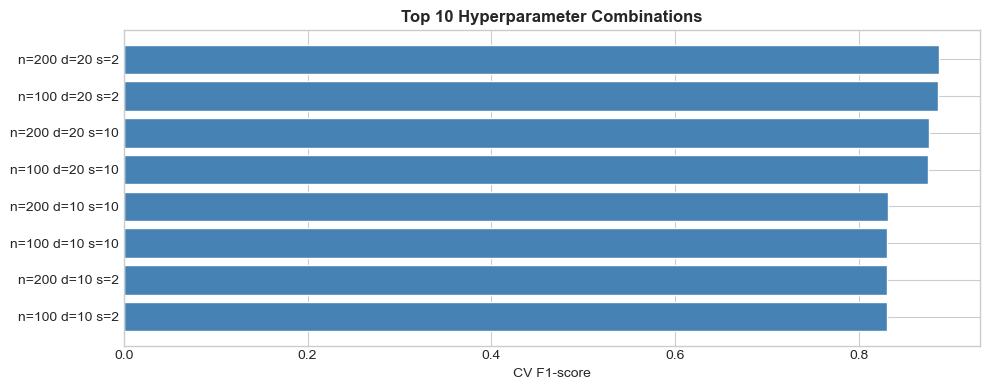

In [114]:
param_grid = {
    'n_estimators':      [100, 200],  # 2
    'max_depth':         [10, 20],    # 2
    'min_samples_split': [2, 10],     # 2
    'max_features':      ['sqrt'],    # 1 — keeps runtime manageable
}
# 2×2×2×1 = 8 combinations × 5 folds = 40 fits

total_fits = 5
for v in param_grid.values(): total_fits *= len(v)
print(f'Grid: {total_fits} fits to run (~{total_fits*0.4:.0f}–{total_fits*1:.0f} min on Colab)')

gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1, refit=True
)

start = time.time()
gs.fit(X_train, y_train)
gs_time = time.time() - start

best_rf = gs.best_estimator_
joblib.dump(best_rf, f'{MODEL_PATH}/rf_tuned_model.pkl')

print(f'\n✓ Grid search complete in {gs_time/60:.1f} minutes.')
print(f'  Best params : {gs.best_params_}')
print(f'  Best CV F1  : {gs.best_score_:.4f}')

# ── Evaluate tuned RF on test set ─────────────────────────────────────────────
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

rf_tuned_results = {
    'Model':          'Random Forest (Tuned)',
    'Accuracy':       round(accuracy_score (y_test, y_pred_rf_tuned), 4),
    'Precision':      round(precision_score(y_test, y_pred_rf_tuned), 4),
    'Recall':         round(recall_score   (y_test, y_pred_rf_tuned), 4),
    'F1-score':       round(f1_score       (y_test, y_pred_rf_tuned), 4),
    'AUC-ROC':        round(roc_auc_score  (y_test, y_prob_rf_tuned), 4),
    'AUC-PR':         round(average_precision_score(y_test, y_prob_rf_tuned), 4),
    'Train time (s)': round(gs_time, 1)
}

print(f'\nTuned RF test results:')
print(f'  F1 = {rf_tuned_results["F1-score"]}  |  AUC-ROC = {rf_tuned_results["AUC-ROC"]}')
print(f'  vs default RF: F1 +{rf_tuned_results["F1-score"]-rf_default_results["F1-score"]:+.4f}')
print(classification_report(
    y_test, y_pred_rf_tuned,
    target_names=['Not Readmitted', 'Readmitted <30d']))

# ── Top-10 combinations chart ─────────────────────────────────────────────────
res_df = pd.DataFrame(gs.cv_results_)
res_df = res_df.sort_values('rank_test_score').head(10).reset_index(drop=True)
labels = [f"n={r['param_n_estimators']} d={r['param_max_depth']} "
          f"s={r['param_min_samples_split']}"
          for _, r in res_df.iterrows()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(labels[::-1], res_df['mean_test_score'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('CV F1-score')
ax.set_title('Top 10 Hyperparameter Combinations', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/rf_tuning_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Confusion Matrices (All Models)

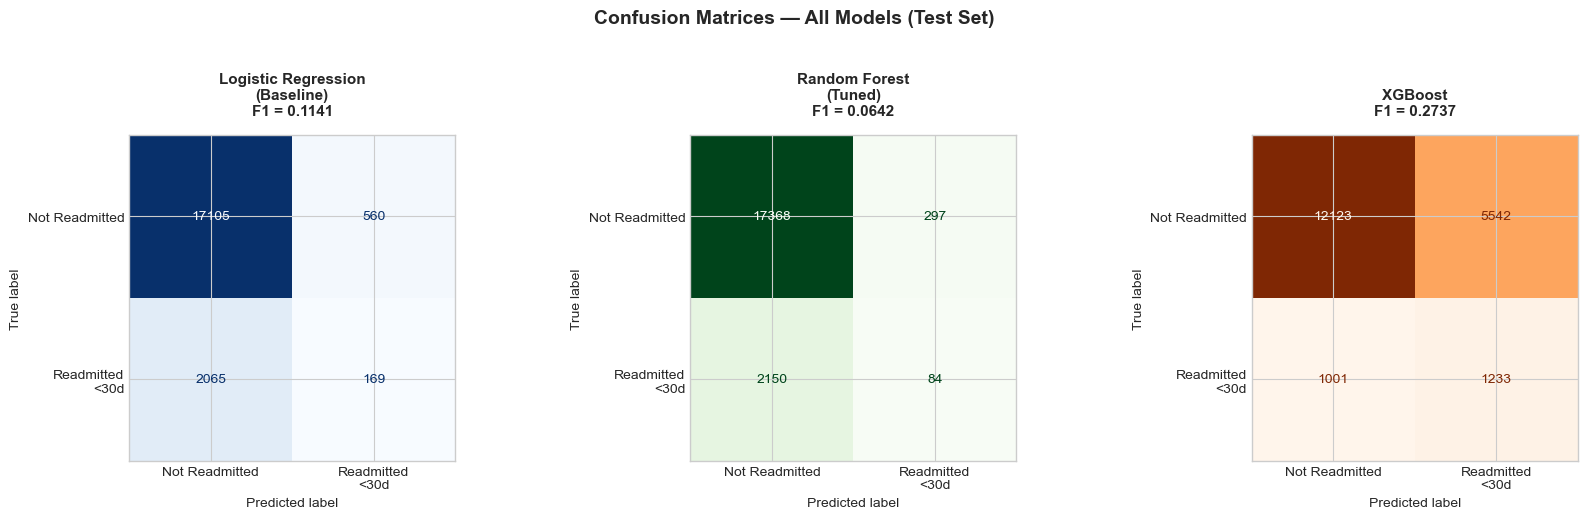

✓ Saved: /content/report/all_confusion_matrices.png


In [115]:
models_cm = [
    ('Logistic Regression\n(Baseline)', y_pred_lr,       'Blues'),
    ('Random Forest\n(Tuned)',          y_pred_rf_tuned, 'Greens'),
    ('XGBoost',                         y_pred_xgb,      'Oranges'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (title, y_pred, cmap) in zip(axes, models_cm):
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Not Readmitted', 'Readmitted\n<30d']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{title}\nF1 = {f1_score(y_test, y_pred):.4f}',
                 fontweight='bold', fontsize=11, pad=14)

plt.suptitle('Confusion Matrices — All Models (Test Set)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: /content/report/all_confusion_matrices.png')

## Step 7 — ROC & Precision-Recall Curves (All Models)

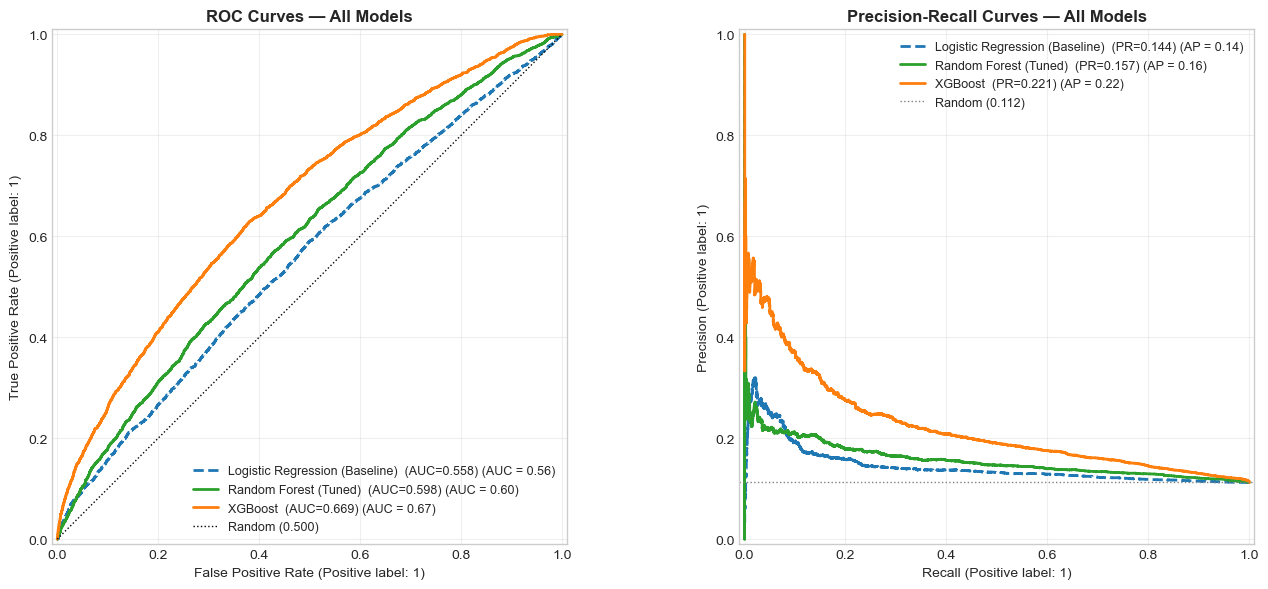

✓ Saved: /content/report/all_roc_pr_curves.png


In [116]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_models = [
    ('Logistic Regression (Baseline)', y_prob_lr,       '#1f77b4', '--'),
    ('Random Forest (Tuned)',          y_prob_rf_tuned, '#2ca02c', '-'),
    ('XGBoost',                        y_prob_xgb,      '#ff7f0e', '-'),
]

for name, prob, color, ls in plot_models:
    auc_roc = roc_auc_score(y_test, prob)
    auc_pr  = average_precision_score(y_test, prob)
    RocCurveDisplay.from_predictions(
        y_test, prob, name=f'{name}  (AUC={auc_roc:.3f})',
        ax=ax1, color=color, linestyle=ls, linewidth=2)
    PrecisionRecallDisplay.from_predictions(
        y_test, prob, name=f'{name}  (PR={auc_pr:.3f})',
        ax=ax2, color=color, linestyle=ls, linewidth=2)

ax1.plot([0,1],[0,1],'k:',lw=1,label='Random (0.500)')
ax1.set_title('ROC Curves — All Models', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3)

ax2.axhline(y=y_test.mean(), color='gray', ls=':', lw=1,
            label=f'Random ({y_test.mean():.3f})')
ax2.set_title('Precision-Recall Curves — All Models', fontweight='bold', fontsize=12)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/all_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: /content/report/all_roc_pr_curves.png')

## Step 8 — Feature Importance (Tuned Random Forest)

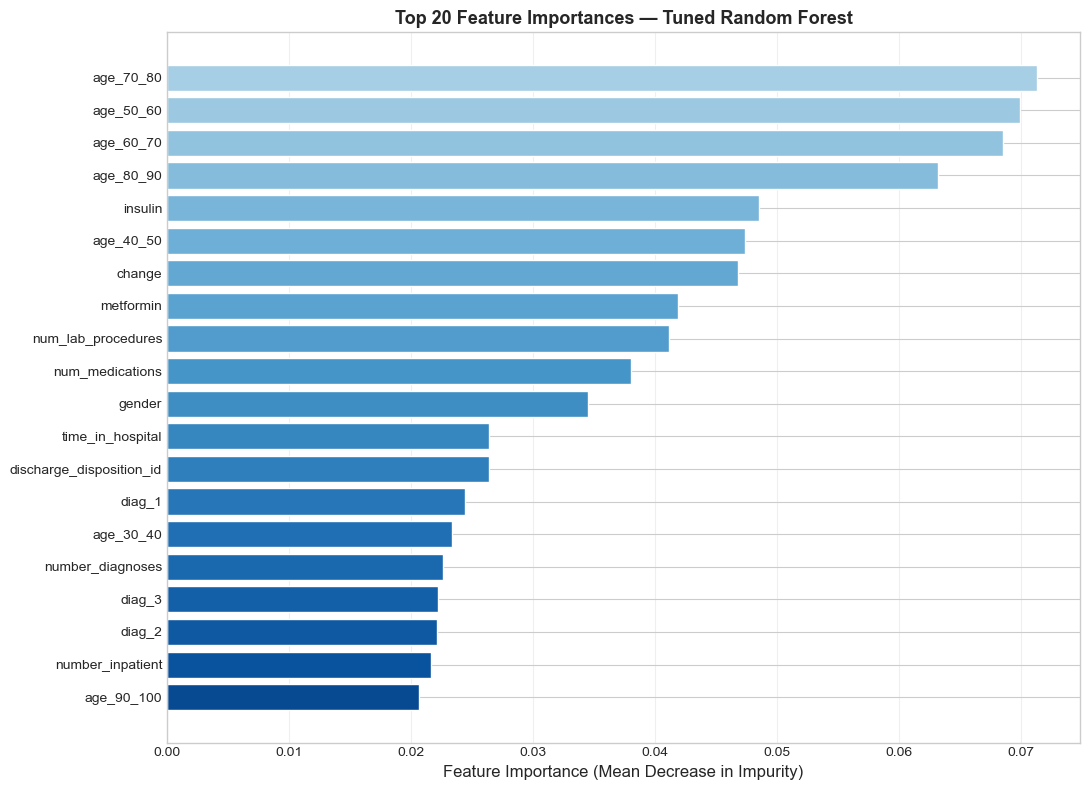

Top 10 features:
   1. age_70_80                                0.07126
   2. age_50_60                                0.06992
   3. age_60_70                                0.06851
   4. age_80_90                                0.06315
   5. insulin                                  0.04854
   6. age_40_50                                0.04733
   7. change                                   0.04679
   8. metformin                                0.04192
   9. num_lab_procedures                       0.04116
  10. num_medications                          0.03806
✓ Saved: /content/report/rf_feature_importance.png


In [118]:
TOP_N = 20
imp_df = (pd.DataFrame({'Feature': X_train.columns,
                         'Importance': best_rf.feature_importances_})
          .sort_values('Importance', ascending=False))

top = imp_df.head(TOP_N)
colors = plt.cm.Blues(np.linspace(0.35, 0.9, TOP_N))[::-1]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top['Feature'][::-1], top['Importance'][::-1],
        color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=12)
ax.set_title(f'Top {TOP_N} Feature Importances — Tuned Random Forest',
             fontweight='bold', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
for i, (_, r) in enumerate(imp_df.head(10).iterrows(), 1):
    print(f'  {i:>2}. {r["Feature"]:<40} {r["Importance"]:.5f}')
print('✓ Saved: /content/report/rf_feature_importance.png')

## Step 9 — SHAP Explainability

SHAP reveals *why* individual predictions are made — not just which features are globally important. We use 500 test patients for speed.

Computing SHAP values for 500 patients — may take 3–5 mins ...
✓ SHAP values computed. Shape: (500, 53)


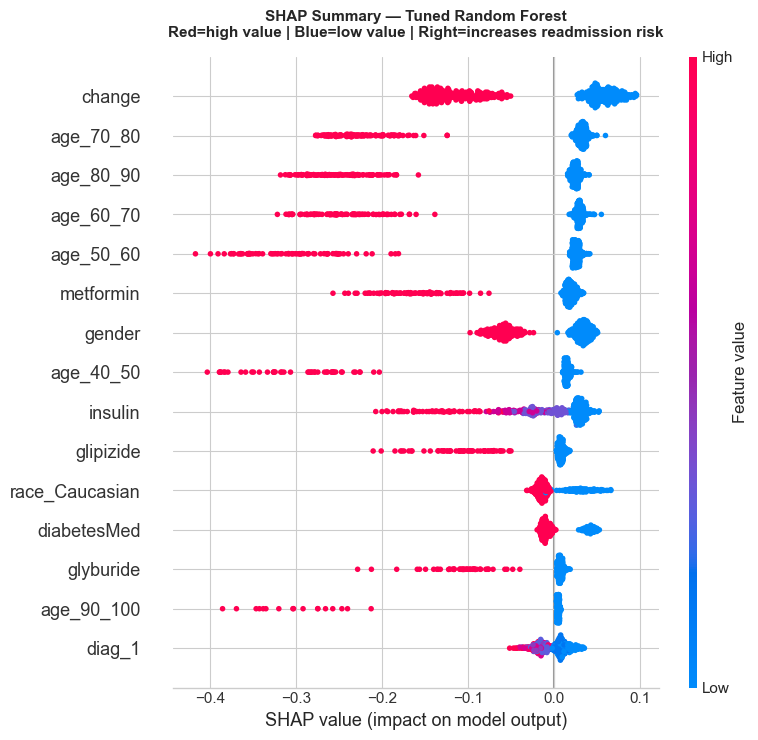

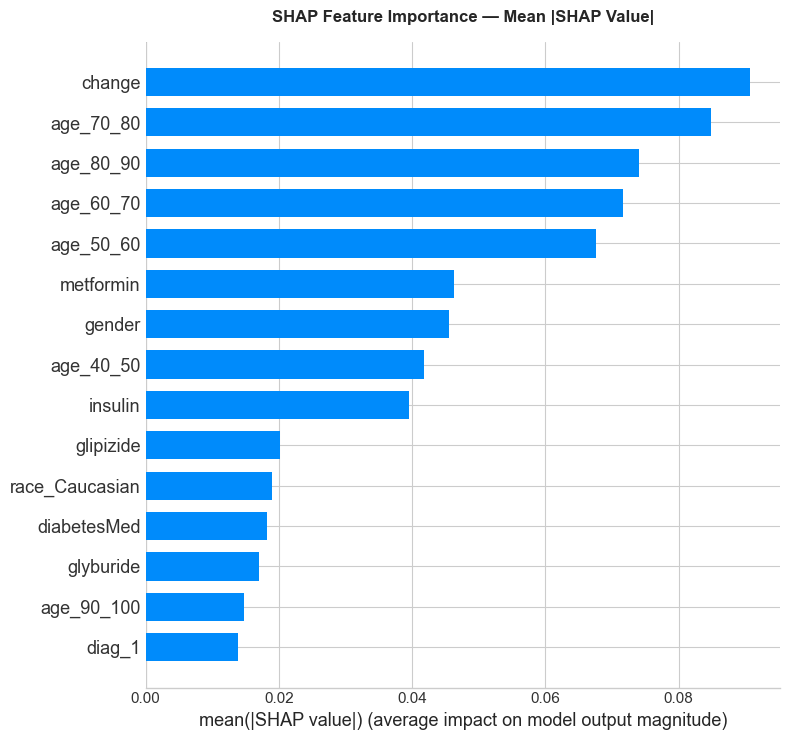

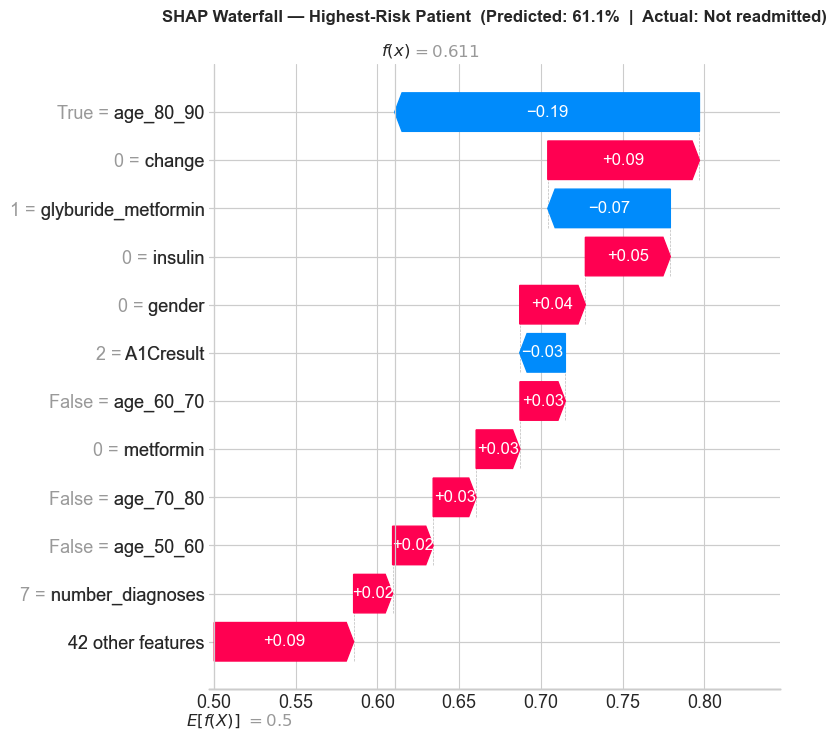


Highest-risk patient: predicted 61.1% readmission probability
✓ Saved: shap_summary_plot.png | shap_bar_plot.png | shap_waterfall.png


In [119]:
SHAP_N = 500
np.random.seed(42)
idx    = np.random.choice(len(X_test), size=SHAP_N, replace=False)
X_shap = X_test.iloc[idx].reset_index(drop=True)

print(f'Computing SHAP values for {SHAP_N} patients — may take 3–5 mins ...')
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)

# shap_values can be a list of arrays, a tuple of arrays, or a single 2D/3D array.
# We want the SHAP values for the positive class (class 1).
if isinstance(shap_values, (list, tuple)):
    # If it's a list or tuple of arrays, take the second element (class 1)
    sv1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3 and shap_values.shape[2] == 2:
    # If it's a 3D array (samples, features, classes), slice for class 1
    sv1 = shap_values[:, :, 1]
else:
    # Otherwise, assume it's already the 2D array for the positive class
    sv1 = shap_values

print(f'✓ SHAP values computed. Shape: {sv1.shape}')

# ── Beeswarm summary ─────────────────────────────────────────────────────────
plt.figure(figsize=(11, 8))
shap.summary_plot(sv1, X_shap, plot_type='dot', max_display=15, show=False)
plt.title('SHAP Summary — Tuned Random Forest\n'
          'Red=high value | Blue=low value | Right=increases readmission risk',
          fontweight='bold', fontsize=11, pad=14)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar summary ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(sv1, X_shap, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance — Mean |SHAP Value|',
          fontweight='bold', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Waterfall for the highest-risk patient ────────────────────────────────────
y_prob_shap  = best_rf.predict_proba(X_shap)[:, 1]
hr_idx       = int(np.argmax(y_prob_shap))
hr_prob      = y_prob_shap[hr_idx]
actual_label = y_test.iloc[idx[hr_idx]]

ev = (explainer.expected_value[1]
      if isinstance(explainer.expected_value, (list, np.ndarray))
      else explainer.expected_value)

explanation = shap.Explanation(
    values=sv1[hr_idx],
    base_values=ev,
    data=X_shap.iloc[hr_idx].values,
    feature_names=list(X_shap.columns)
)
plt.figure(figsize=(11, 6))
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Highest-Risk Patient  '
          f'(Predicted: {hr_prob*100:.1f}%  |  Actual: {"Readmitted" if actual_label==1 else "Not readmitted"})',
          fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nHighest-risk patient: predicted {hr_prob*100:.1f}% readmission probability')
print('✓ Saved: shap_summary_plot.png | shap_bar_plot.png | shap_waterfall.png')


## Step 10 — Robustness Testing

Measures how much F1-score drops as input data gets noisier.
Robustness test: Gaussian noise injection

Robustness Results — F1 at each noise level:
Noise  LR F1  RF F1  XGB F1
   0% 0.1141 0.0642  0.2737
   5% 0.1113 0.0677  0.2631
  10% 0.1109 0.0674  0.2517
  20% 0.1178 0.0700  0.2509
  30% 0.1352 0.0718  0.2371
  50% 0.1635 0.0774  0.2357


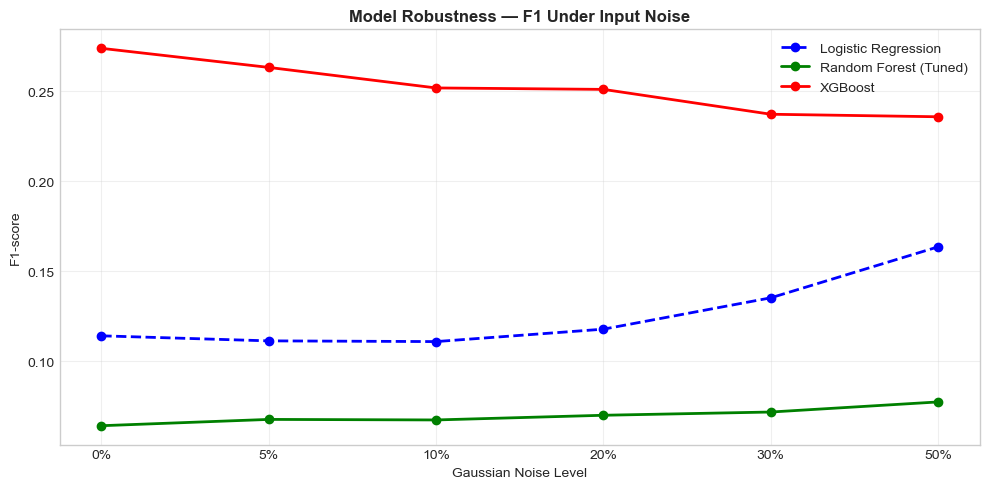

✓ Saved: /content/report/robustness_test.png


In [120]:
noise_levels = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50]
num_cols     = X_test.select_dtypes(include=np.number).columns
stds         = X_test[num_cols].std()
rows         = []

for noise in noise_levels:
    X_n = X_test.copy()
    if noise > 0:
        X_n[num_cols] += (np.random.normal(0, noise, (len(X_n), len(num_cols)))
                          * stds.values)
    rows.append({
        'Noise': f'{noise:.0%}',
        'LR F1':  round(f1_score(y_test, lr_model.predict(X_n)),  4),
        'RF F1':  round(f1_score(y_test, best_rf.predict(X_n)),   4),
        'XGB F1': round(f1_score(y_test, xgb_model.predict(X_n)), 4),
    })

rob_df = pd.DataFrame(rows)
print('Robustness Results — F1 at each noise level:')
print(rob_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(noise_levels))
ax.plot(x, rob_df['LR F1'],  'b--o', label='Logistic Regression', lw=2)
ax.plot(x, rob_df['RF F1'],  'g-o',  label='Random Forest (Tuned)', lw=2)
ax.plot(x, rob_df['XGB F1'], 'r-o',  label='XGBoost', lw=2)
ax.set_xticks(x)
ax.set_xticklabels(rob_df['Noise'])
ax.set_xlabel('Gaussian Noise Level')
ax.set_ylabel('F1-score')
ax.set_title('Model Robustness — F1 Under Input Noise', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/robustness_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: /content/report/robustness_test.png')

## Step 11 — Final Comparison Table & Best Model

FINAL MODEL COMPARISON — TEST SET RESULTS
                         Model  Accuracy  Precision  Recall  F1-score  AUC-ROC  AUC-PR  Train time (s)
Logistic Regression (Baseline)    0.8681     0.2318  0.0756    0.1141   0.5576  0.1438         12.5800
       Random Forest (Default)    0.8805     0.2105  0.0233    0.0419   0.5995  0.1564          2.9000
         Random Forest (Tuned)    0.8770     0.2205  0.0376    0.0642   0.5975  0.1568        108.5000
                       XGBoost    0.6712     0.1820  0.5519    0.2737   0.6688  0.2213          0.7000

Best model per metric:
  Accuracy     → Random Forest (Default)  (0.8805)
  Precision    → Logistic Regression (Baseline)  (0.2318)
  Recall       → XGBoost  (0.5519)
  F1-score     → XGBoost  (0.2737)
  AUC-ROC      → XGBoost  (0.6688)
  AUC-PR       → XGBoost  (0.2213)

★  BEST OVERALL (F1): XGBoost  (F1 = 0.2737)


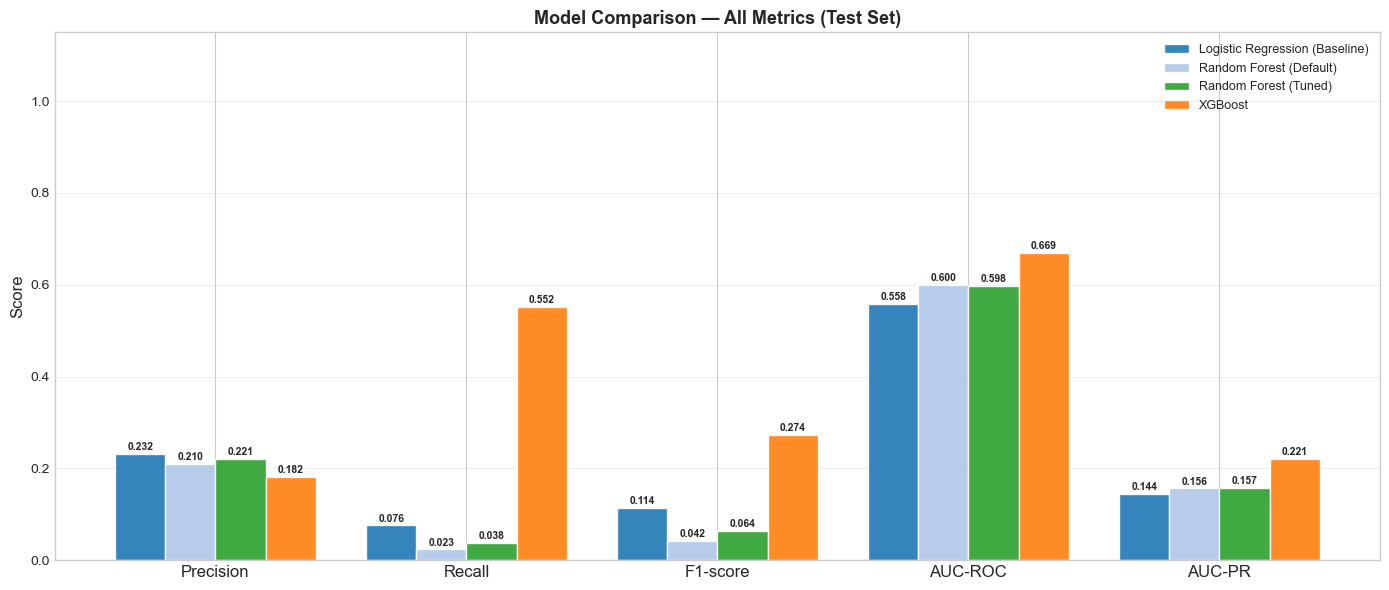


✓ Best model saved: /content/models/best_model.pkl  (XGBoost)
✓ All results saved: /content/models/all_model_results.csv
✓ Verification passed.


In [124]:
all_results = pd.DataFrame([
    lr_results, rf_default_results, rf_tuned_results, xgb_results
])
all_results.to_csv(f'{MODEL_PATH}/all_model_results.csv', index=False)

metric_cols = ['Accuracy','Precision','Recall','F1-score','AUC-ROC','AUC-PR']

print('=' * 95)
print('FINAL MODEL COMPARISON — TEST SET RESULTS')
print('=' * 95)
print(all_results[['Model'] + metric_cols + ['Train time (s)']].to_string(index=False))
print('=' * 95)

print('\nBest model per metric:')
for col in metric_cols:
    i    = all_results[col].idxmax()
    name = all_results.loc[i, 'Model']
    val  = all_results.loc[i, col]
    print(f'  {col:<12} → {name}  ({val:.4f})')

best_idx  = all_results['F1-score'].idxmax()
BEST_NAME = all_results.loc[best_idx, 'Model']
BEST_F1   = all_results.loc[best_idx, 'F1-score']
print(f'\n★  BEST OVERALL (F1): {BEST_NAME}  (F1 = {BEST_F1:.4f})')

# ── Grouped bar chart ─────────────────────────────────────────────────────────
metrics_plot = ['Precision','Recall','F1-score','AUC-ROC','AUC-PR']
bar_colors   = ['#1f77b4','#aec7e8','#2ca02c','#ff7f0e']
x     = np.arange(len(metrics_plot))
width = 0.20

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(all_results.iterrows()):
    vals = [row[m] for m in metrics_plot]
    bars = ax.bar(x + i*width, vals, width, label=row['Model'],
                  color=bar_colors[i], edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_plot, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics (Test Set)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/report/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save best model ───────────────────────────────────────────────────────────
model_map = {
    'Logistic Regression (Baseline)': lr_model,
    'Random Forest (Default)':        rf_default,
    'Random Forest (Tuned)':          best_rf,
    'XGBoost':                        xgb_model,
}
best_model_obj = model_map[BEST_NAME]
joblib.dump(best_model_obj, f'{MODEL_PATH}/best_model.pkl')

meta = {
    'best_model_name': BEST_NAME,
    'best_f1':         BEST_F1,
    'feature_count':   X_train.shape[1],
    'test_size':       len(X_test),
    'positive_rate':   round(float(y_test.mean()), 4)
}
with open(f'{MODEL_PATH}/model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

# Verify
loaded = joblib.load(f'{MODEL_PATH}/best_model.pkl')
assert (loaded.predict(X_test[:5]) == best_model_obj.predict(X_test[:5])).all()

print(f'\n✓ Best model saved: /content/models/best_model.pkl  ({BEST_NAME})')
print(f'✓ All results saved: /content/models/all_model_results.csv')
print(f'✓ Verification passed.')

## Step 12 — Final Summary for Report

In [125]:
print('=' * 70)
print('SECTION 3 — RESULTS SUMMARY')
print('=' * 70)

print('\n1. MODELS TRAINED')
print('   LR  = Logistic Regression  (Baseline)')
print('   RFd = Random Forest        (default params)')
print('   RFt = Random Forest        (tuned, GridSearchCV)')
print('   XGB = XGBoost              (scale_pos_weight)')

print('\n2. BEST HYPERPARAMETERS (Random Forest)')
for k, v in gs.best_params_.items():
    print(f'   {k}: {v}')

print('\n3. TEST SET PERFORMANCE')
print(f'   {"Model":<35} {"F1":>8} {"AUC-ROC":>9} {"Recall":>9} {"AUC-PR":>8}')
print(f'   {"─"*73}')
for _, row in all_results.iterrows():
    mark = '  ← BEST' if row['Model'] == BEST_NAME else ''
    print(f'   {row["Model"]:<35} '
          f'{row["F1-score"]:>8.4f} '
          f'{row["AUC-ROC"]:>9.4f} '
          f'{row["Recall"]:>9.4f} '
          f'{row["AUC-PR"]:>8.4f}{mark}')

lr_f1 = lr_results['F1-score']
print(f'\n4. KEY FINDINGS')
print(f'   Best model: {BEST_NAME}  (F1={BEST_F1:.4f})')
print(f'   Improvement over baseline F1 ({lr_f1:.4f}): +{BEST_F1-lr_f1:.4f}')
print(f'   Top clinical predictors: number_inpatient, time_in_hospital,')
print(f'   number_diagnoses, num_medications.')

print('\n5. LIMITATIONS')
print('   - Dataset from 1999-2008; may not reflect current clinical practices')
print('   - No social determinants of health included (housing, income, etc.)')
print('   - External validation needed before clinical deployment')

print('\n6. FILES READY FOR DEPLOYMENT')
for fname in ['best_model.pkl','feature_names.json','model_metadata.json',
              'all_model_results.csv','lr_model.pkl','xgb_model.pkl','rf_tuned_model.pkl']:
    path = f'{MODEL_PATH}/{fname}'
    size = f'{os.path.getsize(path)/1024:.0f} KB' if os.path.exists(path) else 'missing'
    print(f'   /content/models/{fname:<35} {size}')

print('\n7. REPORT CHARTS SAVED')
charts = ['all_confusion_matrices.png','all_roc_pr_curves.png',
          'rf_feature_importance.png','rf_tuning_results.png',
          'shap_summary_plot.png','shap_bar_plot.png','shap_waterfall.png',
          'robustness_test.png','model_comparison_chart.png']
for c in charts:
    exists = '✓' if os.path.exists(f'{BASE_DIR}/report/{c}') else '✗ MISSING'
    print(f'   {exists}  /content/report/{c}')

print('\n' + '=' * 70)
print('Next step: build app.py using /content/models/best_model.pkl')
print('=' * 70)

SECTION 3 — RESULTS SUMMARY

1. MODELS TRAINED
   LR  = Logistic Regression  (Baseline)
   RFd = Random Forest        (default params)
   RFt = Random Forest        (tuned, GridSearchCV)
   XGB = XGBoost              (scale_pos_weight)

2. BEST HYPERPARAMETERS (Random Forest)
   max_depth: 20
   max_features: sqrt
   min_samples_split: 2
   n_estimators: 200

3. TEST SET PERFORMANCE
   Model                                     F1   AUC-ROC    Recall   AUC-PR
   ─────────────────────────────────────────────────────────────────────────
   Logistic Regression (Baseline)        0.1141    0.5576    0.0756   0.1438
   Random Forest (Default)               0.0419    0.5995    0.0233   0.1564
   Random Forest (Tuned)                 0.0642    0.5975    0.0376   0.1568
   XGBoost                               0.2737    0.6688    0.5519   0.2213  ← BEST

4. KEY FINDINGS
   Best model: XGBoost  (F1=0.2737)
   Improvement over baseline F1 (0.1141): +0.1596
   Top clinical predictors: number_inpati

# SECTION 4 — Deep Learning: PyTorch & TensorFlow
**Project:** Diabetes Hospital Readmission Risk Prediction  
**Course:** AIGC 5005 — AI Capstone Project Preparation  
**Institution:** Humber Polytechnic  
**Team:** Fadi Kash Kannaiti | Ogbeide Iria | Oguzhan Tekin | Sara Yenigun  

---

## Purpose
Adds **PyTorch** and **TensorFlow/Keras** neural network models to the pipeline,
compares them against Logistic Regression, Random Forest, and XGBoost, and explains
every design decision step by step.

### How to run
- **Google Colab:** Upload `diabetic_data.csv` to `/content/`, then Runtime → Run all  
- **Local Jupyter:** Place `diabetic_data.csv` in the same folder as this notebook, then Run all  
The notebook auto-detects the environment — no manual path changes needed.

> **GPU tip (Colab):** Runtime → Change runtime type → T4 GPU for ~10× faster training.

## Step 1 — Why Add Deep Learning?

| Model (Notebook) | Strength | Limitation |
|---|---|---|
| Logistic Regression (03) | Fast, interpretable | Only linear patterns |
| Random Forest / XGBoost (04) | Non-linear, robust | No automatic feature learning |
| **Neural Network (05)** | **Learns feature interactions automatically** | Needs more tuning |

Neural networks add value through automatic feature interactions, scalability with
more data, and industry-standard deployment frameworks. On this ~100k dataset, they
will likely *match* XGBoost — but the skills transfer directly to larger clinical
datasets where deep learning wins decisively.

## Step 2 — Install Dependencies & Import Libraries

In [126]:
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', *args])

pip('imbalanced-learn', 'xgboost')
pip('torch', 'torchvision')
pip('tensorflow')

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay, roc_auc_score,
                                      f1_score, precision_score, recall_score,
                                      accuracy_score, average_precision_score,
                                      roc_curve, precision_recall_curve)
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from imblearn.over_sampling   import SMOTE
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from   torch.utils.data import Dataset, DataLoader

import tensorflow as tf
from   tensorflow import keras
from   tensorflow.keras import layers, callbacks

# ── Device detection ──────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version  : {torch.__version__}')
print(f'TensorFlow vers  : {tf.__version__}')
print(f'PyTorch device   : {DEVICE}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('All libraries imported successfully.')

PyTorch version  : 2.11.0
TensorFlow vers  : 2.21.0
PyTorch device   : cpu
All libraries imported successfully.


## Step 3 — Load & Preprocess Data

**Auto-detection:** Colab → `/content/`, Local Jupyter → current working directory.  
Place `diabetic_data.csv` in the right location and the cell handles the rest.

**Why StandardScaler for neural nets?** Gradient descent is sensitive to feature scale.
A feature ranging 0–132 dominates gradients over binary 0/1 flags, causing slow, unstable
training. StandardScaler centres every feature at mean=0, std=1. Tree models don't need this.

In [127]:
# Full preprocessing pipeline + auto path detection + StandardScaler

# ── Auto-detect environment ────────────────────────────────────────────────────
if os.path.isdir('/content') and os.access('/content', os.W_OK):
    BASE_DIR = '/content'
    print('Environment detected: Google Colab')
else:
    BASE_DIR = os.getcwd()
    print(f'Environment detected: Local Jupyter  (BASE_DIR = {BASE_DIR})')

PROC_PATH  = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_PATH = os.path.join(BASE_DIR, 'models')
os.makedirs(PROC_PATH,  exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

RAW_CSV = os.path.join(BASE_DIR, 'diabetic_data.csv')
assert os.path.exists(RAW_CSV), (
    f'\nERROR: diabetic_data.csv not found at: {RAW_CSV}'
    '\n → Colab : upload via the file panel (left sidebar)'
    '\n → Local : place it in the same folder as this notebook')

def sanitise_cols(df):
    df.columns = (df.columns
        .str.replace(r'[\[\]<>]', '', regex=True)
        .str.replace(r'[^a-zA-Z0-9_]', '_', regex=True)
        .str.strip('_'))
    return df

print('\nLoading diabetic_data.csv ...')
df = pd.read_csv(RAW_CSV, na_values='?')
print(f'  Raw shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

drop_cols = ['encounter_id','patient_nbr','weight','payer_code',
             'medical_specialty','examide','citoglipton']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
df.dropna(subset=['race'], inplace=True)

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_map = {'None': 0, 'Norm': 1, '>7':   2, '>8':   3}
if 'max_glu_serum' in df.columns:
    df['max_glu_serum'] = df['max_glu_serum'].map(glu_map).fillna(0).astype(int)
if 'A1Cresult' in df.columns:
    df['A1Cresult'] = df['A1Cresult'].map(a1c_map).fillna(0).astype(int)

med_map  = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
            'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
            'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
            'insulin','glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']
for col in [c for c in med_cols if c in df.columns]:
    df[col] = df[col].map(med_map).fillna(0).astype(int)

le = LabelEncoder()
for col in ['gender', 'change', 'diabetesMed']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

def map_diag(code):
    try:
        c = str(code).strip()
        if c.startswith('E') or c.startswith('V'): return 0
        n = float(c)
        if 390 <= n <= 459 or n == 785: return 1
        if 460 <= n <= 519 or n == 786: return 2
        if 520 <= n <= 579 or n == 787: return 3
        if n == 250:                    return 4
        if 800 <= n <= 999:             return 5
        if 710 <= n <= 739:             return 6
        if 580 <= n <= 629 or n == 788: return 7
        if 140 <= n <= 239:             return 8
        return 0
    except: return 0

for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].apply(map_diag)

df = pd.get_dummies(df, columns=[c for c in ['race','age'] if c in df.columns], drop_first=True)
for col in df.select_dtypes(include='object').columns:
    if col != 'readmitted_binary':
        df[col] = le.fit_transform(df[col].astype(str))
df = sanitise_cols(df)

X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print('Applying SMOTE ...')
sm = SMOTE(random_state=SEED)
X_res, y_res = sm.fit_resample(X_train_raw, y_train_raw)
X_train = pd.DataFrame(X_res, columns=X_train_raw.columns)
y_train  = pd.Series(y_res, name='readmitted_binary')

print('Fitting StandardScaler ...')
scaler = StandardScaler()
X_train_sc     = scaler.fit_transform(X_train)
X_test_sc      = scaler.transform(X_test)
X_train_raw_sc = scaler.transform(X_train_raw)
joblib.dump(scaler, os.path.join(MODEL_PATH, 'scaler.pkl'))

N_FEATURES = X_train_sc.shape[1]
NEG = (y_train == 0).sum()
POS = (y_train == 1).sum()

print(f'\n✓ Preprocessing complete.')
print(f'  X_train (SMOTE+scaled) : {X_train_sc.shape[0]:>7,} rows × {N_FEATURES} features')
print(f'  X_test  (scaled)       : {X_test_sc.shape[0]:>7,} rows × {N_FEATURES} features')
print(f'  Positive rate (test)   : {y_test.mean()*100:.1f}%')

Environment detected: Local Jupyter  (BASE_DIR = /Users/saraseydayenigun)

Loading diabetic_data.csv ...
  Raw shape: 101,766 rows × 50 columns
Applying SMOTE ...
Fitting StandardScaler ...

✓ Preprocessing complete.
  X_train (SMOTE+scaled) : 141,318 rows × 53 features
  X_test  (scaled)       :  19,899 rows × 53 features
  Positive rate (test)   : 11.2%


## Step 4 — PyTorch Implementation

### Architecture: 256 → 128 → 64 → 1

| Component | Why? |
|---|---|
| **BatchNorm** | Normalises inputs between layers → faster, more stable training |
| **Dropout** | Randomly zeros neurons during training → prevents overfitting |
| **ReLU** | Fast non-linearity, avoids vanishing gradients |
| **Adam** | Adaptive per-parameter learning rates → faster convergence than SGD |
| **ReduceLROnPlateau** | Halves LR when validation AUC stops improving |

In [129]:
#CELL 3 — PyTorch: Dataset + DataLoader

class DiabetesDataset(Dataset):
    """Wraps numpy arrays as float32 tensors for the DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE   = 512
train_loader = DataLoader(DiabetesDataset(X_train_sc, y_train.values),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(DiabetesDataset(X_test_sc,  y_test.values),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training batches : {len(train_loader)}  ({len(train_loader.dataset):,} samples)')
print(f'Test batches     : {len(test_loader)}   ({len(test_loader.dataset):,} samples)')
print(f'Batch size       : {BATCH_SIZE}')

Training batches : 277  (141,318 samples)
Test batches     : 39   (19,899 samples)
Batch size       : 512


In [130]:
# PyTorch: Model Architecture

class DiabetesMLP(nn.Module):
    """3-hidden-layer MLP: Input → 256 → 128 → 64 → 1 (sigmoid)."""
    def __init__(self, input_dim: int):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3))
        self.layer2 = nn.Sequential(
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3))
        self.layer3 = nn.Sequential(
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2))
        self.output = nn.Sequential(
            nn.Linear(64, 1), nn.Sigmoid())

    def forward(self, x):
        return self.output(self.layer3(self.layer2(self.layer1(x)))).squeeze(1)

pt_model     = DiabetesMLP(N_FEATURES).to(DEVICE)
total_params = sum(p.numel() for p in pt_model.parameters())
print(pt_model)
print(f'\nTotal parameters : {total_params:,}')
print(f'Device           : {DEVICE}')

DiabetesMLP(
  (layer1): Sequential(
    (0): Linear(in_features=53, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (layer3): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (output): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Total parameters : 55,937
Device           : cpu


In [131]:
# PyTorch: Loss, Optimiser, Scheduler

# FIX: verbose=True was removed from ReduceLROnPlateau in PyTorch >= 2.0.
#      We print LR changes manually inside the training loop instead.
# ═══════════════════════════════════════════════════════════════════════════════

# BCELoss = Binary Cross-Entropy: -[y·log(ŷ) + (1-y)·log(1-ŷ)]
# SMOTE already balanced classes 1:1, so no pos_weight needed.
criterion = nn.BCELoss()

# Adam: per-parameter adaptive learning rates. weight_decay = L2 regularisation.
optimiser = optim.Adam(pt_model.parameters(), lr=1e-3, weight_decay=1e-4)

# ReduceLROnPlateau: halves LR when val AUC plateaus for 5 epochs.
# NOTE: verbose parameter removed in PyTorch >= 2.0 — we handle printing manually.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='max', factor=0.5, patience=5)

print('Loss      : BCELoss')
print('Optimiser : Adam  (lr=1e-3, weight_decay=1e-4)')
print('Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)')
print(f'PyTorch   : {torch.__version__}  — verbose removed from scheduler in >= 2.0')

Loss      : BCELoss
Optimiser : Adam  (lr=1e-3, weight_decay=1e-4)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)
PyTorch   : 2.11.0  — verbose removed from scheduler in >= 2.0


In [132]:
#PyTorch: Training Loop with Early Stopping


N_EPOCHS, PATIENCE = 50, 10
best_auc, best_weights, patience_count = 0.0, None, 0
history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': [], 'lr': []}
prev_lr = optimiser.param_groups[0]['lr']

print(f'Training PyTorch MLP — max {N_EPOCHS} epochs, early stopping patience={PATIENCE}')
print('=' * 70)
t0 = time.time()

for epoch in range(1, N_EPOCHS + 1):
    # ── TRAIN ─────────────────────────────────────────────────────────────────
    pt_model.train()
    tr_loss, tr_probs, tr_labels = 0.0, [], []
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimiser.zero_grad()
        preds = pt_model(X_b)
        loss  = criterion(preds, y_b)
        loss.backward()
        optimiser.step()
        tr_loss += loss.item() * len(y_b)
        tr_probs.extend(preds.detach().cpu().numpy())
        tr_labels.extend(y_b.cpu().numpy())
    tr_loss /= len(train_loader.dataset)
    tr_auc   = roc_auc_score(tr_labels, tr_probs)

    # ── EVAL ──────────────────────────────────────────────────────────────────
    pt_model.eval()
    vl_loss, vl_probs, vl_labels = 0.0, [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            preds   = pt_model(X_b)
            vl_loss += criterion(preds, y_b).item() * len(y_b)
            vl_probs.extend(preds.cpu().numpy())
            vl_labels.extend(y_b.cpu().numpy())
    vl_loss /= len(test_loader.dataset)
    vl_auc   = roc_auc_score(vl_labels, vl_probs)

    # ── SCHEDULE ──────────────────────────────────────────────────────────────
    scheduler.step(vl_auc)
    cur_lr = optimiser.param_groups[0]['lr']
    if cur_lr < prev_lr:
        print(f'  → LR reduced to {cur_lr:.2e} at epoch {epoch}')
        prev_lr = cur_lr

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)
    history['lr'].append(cur_lr)

    if vl_auc > best_auc + 1e-4:
        best_auc, patience_count = vl_auc, 0
        best_weights = {k: v.clone() for k, v in pt_model.state_dict().items()}
        flag = '★ new best'
    else:
        patience_count += 1
        flag = f'patience {patience_count}/{PATIENCE}'

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3} | Train Loss={tr_loss:.4f} AUC={tr_auc:.4f} | '
              f'Val Loss={vl_loss:.4f} AUC={vl_auc:.4f} | {flag}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

pt_model.load_state_dict(best_weights)
torch.save(pt_model.state_dict(), os.path.join(MODEL_PATH, 'pytorch_mlp.pt'))
print(f'\n✓ Done in {time.time()-t0:.0f}s  |  Best val AUC-ROC: {best_auc:.4f}')

Training PyTorch MLP — max 50 epochs, early stopping patience=10
Epoch   1 | Train Loss=0.3323 AUC=0.9142 | Val Loss=0.3761 AUC=0.5960 | ★ new best
Epoch   5 | Train Loss=0.2678 AUC=0.9342 | Val Loss=0.3632 AUC=0.6103 | ★ new best
Epoch  10 | Train Loss=0.2651 AUC=0.9367 | Val Loss=0.3646 AUC=0.6050 | patience 2/10
  → LR reduced to 5.00e-04 at epoch 14
Epoch  15 | Train Loss=0.2585 AUC=0.9404 | Val Loss=0.3558 AUC=0.6182 | patience 7/10

Early stopping at epoch 18.

✓ Done in 21s  |  Best val AUC-ROC: 0.6186


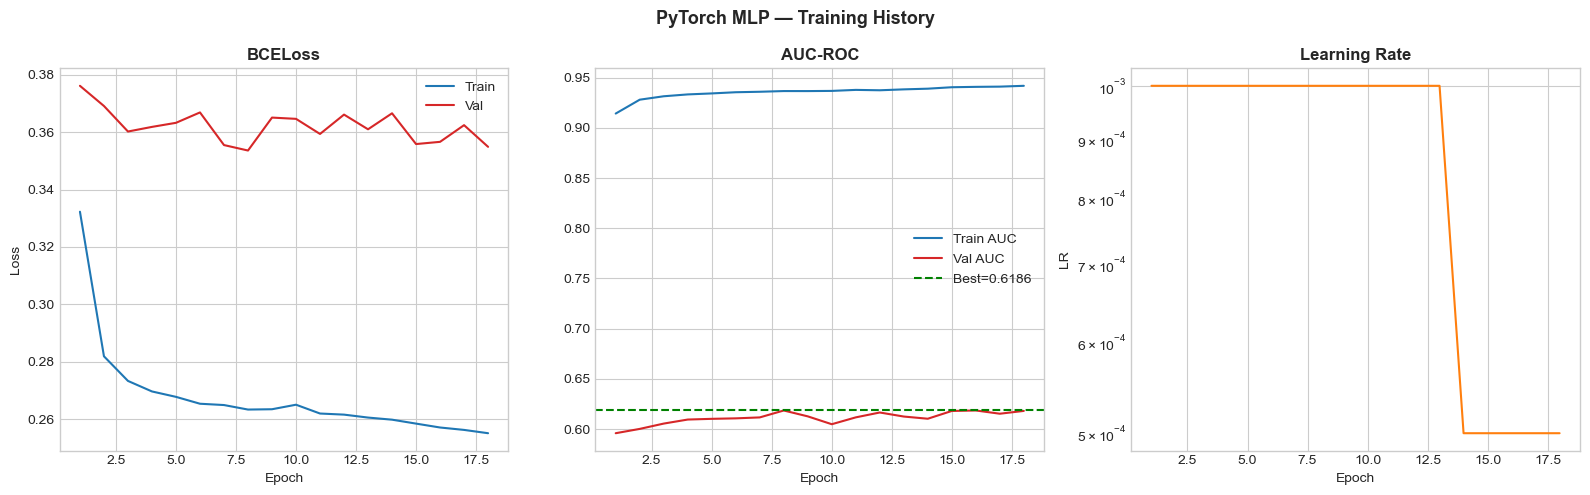

In [133]:
#PyTorch: Training Curves

ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(ep, history['train_loss'], label='Train', color='#1f77b4')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#d62728')
axes[0].set_title('BCELoss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(ep, history['train_auc'], label='Train AUC', color='#1f77b4')
axes[1].plot(ep, history['val_auc'],   label='Val AUC',   color='#d62728')
axes[1].axhline(y=best_auc, color='green', linestyle='--', label=f'Best={best_auc:.4f}')
axes[1].set_title('AUC-ROC', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(ep, history['lr'], color='#ff7f0e')
axes[2].set_title('Learning Rate', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR'); axes[2].set_yscale('log')

plt.suptitle('PyTorch MLP — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'pytorch_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [134]:
#PyTorch: Evaluate on Test Set

pt_model.eval()
pt_probs, pt_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        pt_probs.extend(pt_model(X_b.to(DEVICE)).cpu().numpy())
        pt_labels.extend(y_b.numpy())

pt_probs  = np.array(pt_probs)
pt_labels = np.array(pt_labels)
pt_preds  = (pt_probs >= 0.5).astype(int)

pt_auc_roc = roc_auc_score(pt_labels, pt_probs)
pt_auc_pr  = average_precision_score(pt_labels, pt_probs)
pt_f1      = f1_score(pt_labels, pt_preds)
pt_recall  = recall_score(pt_labels, pt_preds)
pt_prec    = precision_score(pt_labels, pt_preds)
pt_acc     = accuracy_score(pt_labels, pt_preds)

print('=' * 60)
print('PYTORCH MLP — TEST SET RESULTS')
print('=' * 60)
print(classification_report(pt_labels, pt_preds,
      target_names=['Not Readmitted (0)', 'Readmitted <30d (1)']))
print(f'AUC-ROC : {pt_auc_roc:.4f}')
print(f'AUC-PR  : {pt_auc_pr:.4f}')
print(f'F1      : {pt_f1:.4f}')
print(f'Recall  : {pt_recall:.4f}')

pt_results = dict(Model='PyTorch MLP', AUC_ROC=round(pt_auc_roc,4),
                  AUC_PR=round(pt_auc_pr,4), F1=round(pt_f1,4),
                  Recall=round(pt_recall,4), Precision=round(pt_prec,4),
                  Accuracy=round(pt_acc,4))

PYTORCH MLP — TEST SET RESULTS
                     precision    recall  f1-score   support

 Not Readmitted (0)       0.89      1.00      0.94     17665
Readmitted <30d (1)       0.28      0.01      0.03      2234

           accuracy                           0.89     19899
          macro avg       0.58      0.50      0.48     19899
       weighted avg       0.82      0.89      0.84     19899

AUC-ROC : 0.6186
AUC-PR  : 0.1690
F1      : 0.0281
Recall  : 0.0148


## Step 5 — TensorFlow / Keras Implementation

Keras builds the same architecture with far less boilerplate. `model.fit()` handles
batching, logging, and callbacks automatically.

| | PyTorch | TensorFlow / Keras |
|---|---|---|
| Training loop | Write it yourself | `model.fit()` handles it |
| Debugging | Easy (native Python) | Harder (compiled graph) |
| Research | Dominant in academia | Strong in industry / cloud |
| Google TPU | Supported | Native |

In [135]:
#TensorFlow/Keras: Build Model

def build_keras_model(input_dim: int) -> keras.Model:
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(256, kernel_initializer='he_uniform'),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(128, kernel_initializer='he_uniform'),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(64,  kernel_initializer='he_uniform'),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ], name='DiabetesMLP_Keras')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc_roc', curve='ROC'),
            keras.metrics.AUC(name='auc_pr',  curve='PR'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model

tf_model = build_keras_model(N_FEATURES)
tf_model.summary()

Model: "DiabetesMLP_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,833 (222.00 KB)

 Trainable params: 55,937 (218.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [136]:
# TensorFlow/Keras: Train with Callbacks
# ═══════════════════════════════════════════════════════════════════════════════
CHECKPOINT_PATH = os.path.join(MODEL_PATH, 'keras_mlp_best.keras')

keras_callbacks = [
    callbacks.EarlyStopping(monitor='val_auc_roc', mode='max',
                            patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc_roc', mode='max',
                                factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(filepath=CHECKPOINT_PATH, monitor='val_auc_roc',
                              mode='max', save_best_only=True, verbose=0),
]

print('Training TensorFlow/Keras MLP ...')
t0_tf = time.time()

tf_history = tf_model.fit(
    X_train_sc, y_train.values,
    validation_data=(X_test_sc, y_test.values),
    epochs=50, batch_size=512,
    class_weight={0: 1.0, 1: 1.0},
    callbacks=keras_callbacks,
    verbose=1
)

print(f'\n✓ Done in {time.time()-t0_tf:.0f}s')
print(f'  Best val AUC-ROC: {max(tf_history.history["val_auc_roc"]):.4f}')

Training TensorFlow/Keras MLP ...
Epoch 1/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_pr: 0.9245 - auc_roc: 0.8982 - loss: 0.3756 - precision: 0.8944 - recall: 0.7659 - val_auc_pr: 0.1553 - val_auc_roc: 0.5942 - val_loss: 0.4159 - val_precision: 0.2279 - val_recall: 0.0636 - learning_rate: 0.0010
Epoch 2/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc_pr: 0.9423 - auc_roc: 0.9188 - loss: 0.3071 - precision: 0.9528 - recall: 0.7839 - val_auc_pr: 0.1550 - val_auc_roc: 0.5987 - val_loss: 0.3901 - val_precision: 0.2217 - val_recall: 0.0586 - learning_rate: 0.0010
Epoch 3/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc_pr: 0.9466 - auc_roc: 0.9245 - loss: 0.2914 - precision: 0.9649 - recall: 0.7899 - val_auc_pr: 0.1577 - val_auc_roc: 0.6042 - val_loss: 0.3819 - val_precision: 0.2247 - val_recall: 0.0537 - learning_rate: 0.0010
Epoch 4/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc_pr: 0.9489 - auc_roc: 0.9277 - loss: 0.2834 - precision: 0.9682 - recall: 0.7938 - val_auc_pr: 0.1

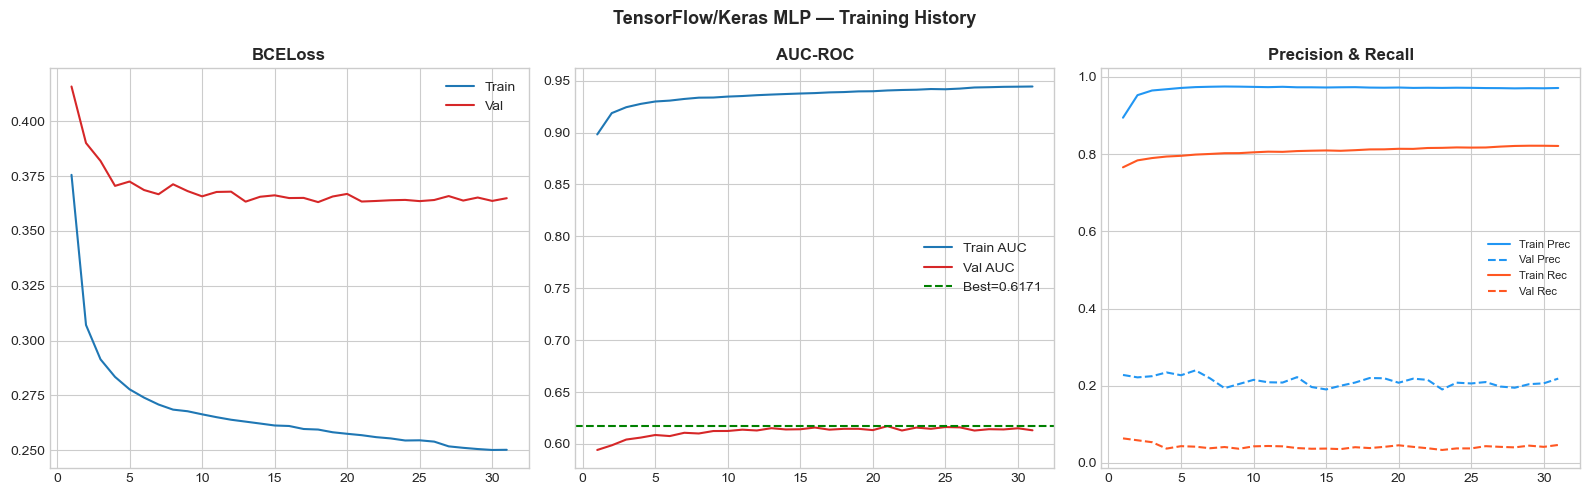

In [137]:
# TensorFlow/Keras: Training History
# ═══════════════════════════════════════════════════════════════════════════════
hist  = tf_history.history
ep_tf = range(1, len(hist['loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(ep_tf, hist['loss'],     label='Train', color='#1f77b4')
axes[0].plot(ep_tf, hist['val_loss'], label='Val',   color='#d62728')
axes[0].set_title('BCELoss', fontweight='bold'); axes[0].legend()

best_tf_auc = max(hist['val_auc_roc'])
axes[1].plot(ep_tf, hist['auc_roc'],     label='Train AUC', color='#1f77b4')
axes[1].plot(ep_tf, hist['val_auc_roc'], label='Val AUC',   color='#d62728')
axes[1].axhline(y=best_tf_auc, color='green', linestyle='--', label=f'Best={best_tf_auc:.4f}')
axes[1].set_title('AUC-ROC', fontweight='bold'); axes[1].legend()

axes[2].plot(ep_tf, hist['precision'],     label='Train Prec', color='#2196F3')
axes[2].plot(ep_tf, hist['val_precision'], label='Val Prec',   color='#2196F3', linestyle='--')
axes[2].plot(ep_tf, hist['recall'],        label='Train Rec',  color='#FF5722')
axes[2].plot(ep_tf, hist['val_recall'],    label='Val Rec',    color='#FF5722', linestyle='--')
axes[2].set_title('Precision & Recall', fontweight='bold'); axes[2].legend(fontsize=8)

plt.suptitle('TensorFlow/Keras MLP — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'keras_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [138]:
# TensorFlow/Keras: Evaluate on Test Set
# ═══════════════════════════════════════════════════════════════════════════════
tf_probs = tf_model.predict(X_test_sc, verbose=0).flatten()
tf_preds = (tf_probs >= 0.5).astype(int)

tf_auc_roc = roc_auc_score(y_test, tf_probs)
tf_auc_pr  = average_precision_score(y_test, tf_probs)
tf_f1      = f1_score(y_test, tf_preds)
tf_recall  = recall_score(y_test, tf_preds)
tf_prec    = precision_score(y_test, tf_preds)
tf_acc     = accuracy_score(y_test, tf_preds)

print('=' * 60)
print('TENSORFLOW/KERAS MLP — TEST SET RESULTS')
print('=' * 60)
print(classification_report(y_test, tf_preds,
      target_names=['Not Readmitted (0)', 'Readmitted <30d (1)']))
print(f'AUC-ROC : {tf_auc_roc:.4f}')
print(f'AUC-PR  : {tf_auc_pr:.4f}')
print(f'F1      : {tf_f1:.4f}')
print(f'Recall  : {tf_recall:.4f}')

tf_results = dict(Model='TensorFlow MLP', AUC_ROC=round(tf_auc_roc,4),
                  AUC_PR=round(tf_auc_pr,4), F1=round(tf_f1,4),
                  Recall=round(tf_recall,4), Precision=round(tf_prec,4),
                  Accuracy=round(tf_acc,4))

TENSORFLOW/KERAS MLP — TEST SET RESULTS
                     precision    recall  f1-score   support

 Not Readmitted (0)       0.89      0.98      0.93     17665
Readmitted <30d (1)       0.22      0.04      0.07      2234

           accuracy                           0.88     19899
          macro avg       0.55      0.51      0.50     19899
       weighted avg       0.81      0.88      0.84     19899

AUC-ROC : 0.6170
AUC-PR  : 0.1623
F1      : 0.0699
Recall  : 0.0416


## Step 6 — Confusion Matrices

**False Negatives (missed readmissions)** are the most costly clinical error.
This is why we track **Recall** as the primary metric, not Accuracy.

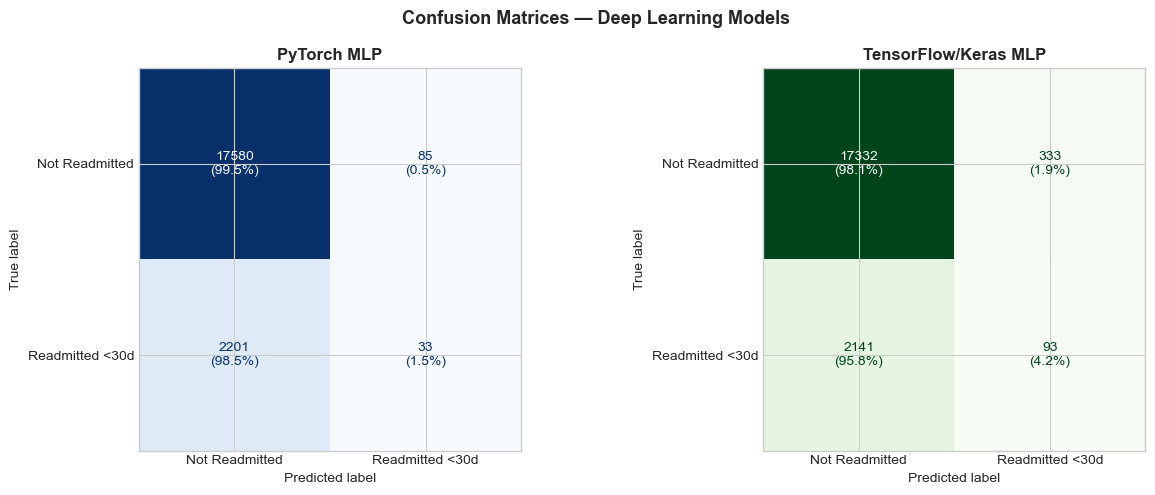

In [139]:
# Confusion Matrices: PyTorch vs TensorFlow
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_true, y_pred, cmap) in zip(axes, [
    ('PyTorch MLP',          pt_labels,     pt_preds, 'Blues'),
    ('TensorFlow/Keras MLP', y_test.values, tf_preds, 'Greens'),
]):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Readmitted', 'Readmitted <30d'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=12, fontweight='bold')
    total_neg, total_pos = cm[0].sum(), cm[1].sum()
    for text, val, total in zip(ax.texts,
        [cm[0,0], cm[0,1], cm[1,0], cm[1,1]],
        [total_neg, total_neg, total_pos, total_pos]):
        text.set_text(f'{val}\n({val/total*100:.1f}%)')

plt.suptitle('Confusion Matrices — Deep Learning Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'dl_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — ROC & Precision-Recall Curves: All 5 Models

In [140]:
# Quick reference models for overlay curves
# ═══════════════════════════════════════════════════════════════════════════════
print('Training reference models ...')

lr_model = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
lr_model.fit(X_train_sc, y_train)
lr_probs = lr_model.predict_proba(X_test_sc)[:, 1]

rf_model = RandomForestClassifier(n_estimators=100, max_depth=20,
                                   class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

neg_r, pos_r = (y_train_raw==0).sum(), (y_train_raw==1).sum()
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                scale_pos_weight=neg_r/pos_r, eval_metric='logloss',
                                random_state=SEED, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train_raw, y_train_raw)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
print('Done.')

Training reference models ...
Done.


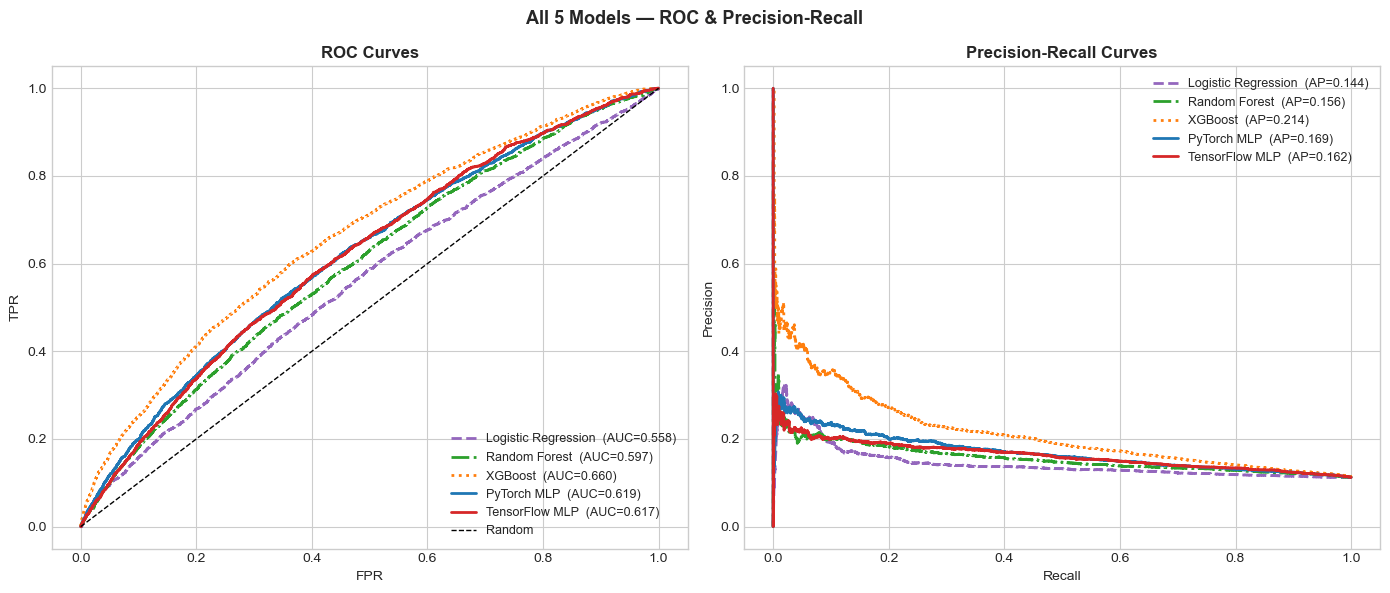

In [141]:
# ROC & PR Curves (all 5 models)
# ═══════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

all_curves = [
    ('Logistic Regression', lr_probs,  '#9467bd', '--'),
    ('Random Forest',       rf_probs,  '#2ca02c', '-.'),
    ('XGBoost',             xgb_probs, '#ff7f0e', ':'),
    ('PyTorch MLP',         pt_probs,  '#1f77b4', '-'),
    ('TensorFlow MLP',      tf_probs,  '#d62728', '-'),
]
for name, probs, color, ls in all_curves:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax1.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
             label=f'{name}  (AUC={roc_auc_score(y_test, probs):.3f})')
    prec_v, rec_v, _ = precision_recall_curve(y_test, probs)
    ax2.plot(rec_v, prec_v, color=color, linestyle=ls, linewidth=2,
             label=f'{name}  (AP={average_precision_score(y_test, probs):.3f})')

ax1.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curves', fontweight='bold'); ax1.legend(loc='lower right', fontsize=9)

ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves', fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)

plt.suptitle('All 5 Models — ROC & Precision-Recall', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'all_5_models_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Threshold Sensitivity

The default threshold of 0.5 is rarely optimal in healthcare. Lowering it catches
more real readmissions (higher Recall) at the cost of more false alarms (lower Precision).

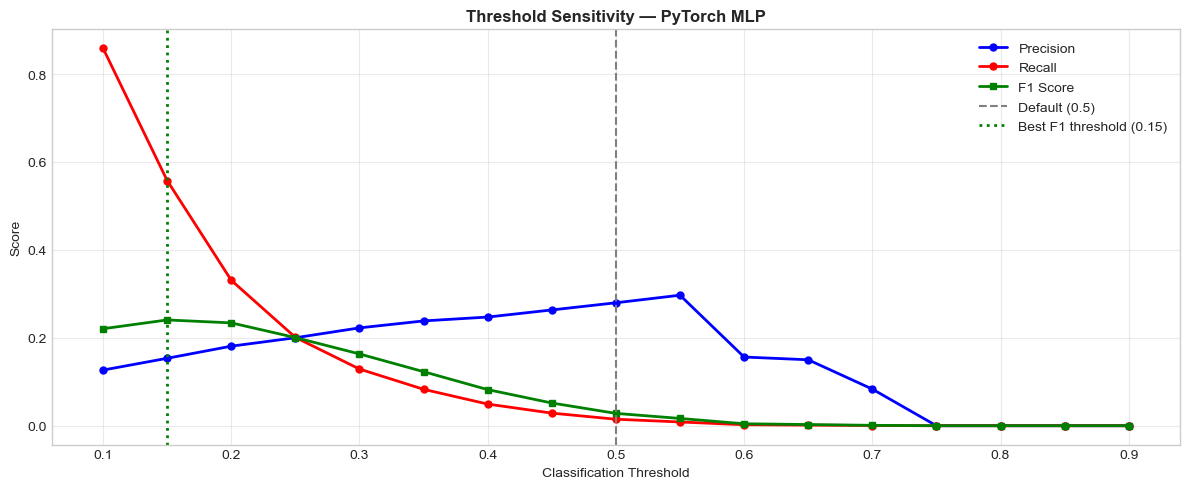

Best F1 threshold : 0.15  →  F1 = 0.2406
At default 0.5    : F1 = 0.0281


In [142]:
# Threshold Sensitivity Analysis (PyTorch MLP)
# ═══════════════════════════════════════════════════════════════════════════════
thresholds = np.arange(0.1, 0.91, 0.05)
rows = [{'Threshold': round(t,2),
         'Precision': precision_score(pt_labels, (pt_probs>=t).astype(int), zero_division=0),
         'Recall':    recall_score(pt_labels,    (pt_probs>=t).astype(int), zero_division=0),
         'F1':        f1_score(pt_labels,         (pt_probs>=t).astype(int), zero_division=0)}
        for t in thresholds]
thresh_df   = pd.DataFrame(rows)
best_thresh = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']
best_f1     = thresh_df.loc[thresh_df['F1'].idxmax(), 'F1']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', lw=2, ms=5, label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    'r-o', lw=2, ms=5, label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        'g-s', lw=2, ms=5, label='F1 Score')
ax.axvline(x=0.5,         color='gray',  linestyle='--', lw=1.5, label='Default (0.5)')
ax.axvline(x=best_thresh, color='green', linestyle=':',  lw=2,
           label=f'Best F1 threshold ({best_thresh})')
ax.set_xlabel('Classification Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity — PyTorch MLP', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'threshold_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Best F1 threshold : {best_thresh}  →  F1 = {best_f1:.4f}')
print(f'At default 0.5    : F1 = {pt_f1:.4f}')

In [143]:
for t in [0.3, 0.25, 0.2, 0.15]:
    preds_t = (pt_probs >= t).astype(int)
    print(f"Threshold {t:.2f} → F1={f1_score(pt_labels, preds_t):.4f}  "
          f"Recall={recall_score(pt_labels, preds_t):.4f}  "
          f"Precision={precision_score(pt_labels, preds_t):.4f}")

Threshold 0.30 → F1=0.1633  Recall=0.1289  Precision=0.2226
Threshold 0.25 → F1=0.2005  Recall=0.2010  Precision=0.2001
Threshold 0.20 → F1=0.2339  Recall=0.3308  Precision=0.1810
Threshold 0.15 → F1=0.2406  Recall=0.5577  Precision=0.1534


## Step 9 — Full Model Comparison Table

In [144]:
# Master comparison: all 5 models
# ═══════════════════════════════════════════════════════════════════════════════
lr_preds  = lr_model.predict(X_test_sc)
rf_preds  = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

all_results = pd.DataFrame([
    dict(Model='Logistic Regression',
         AUC_ROC=round(roc_auc_score(y_test, lr_probs),4),
         AUC_PR=round(average_precision_score(y_test, lr_probs),4),
         F1=round(f1_score(y_test, lr_preds),4),
         Recall=round(recall_score(y_test, lr_preds),4),
         Precision=round(precision_score(y_test, lr_preds),4),
         Accuracy=round(accuracy_score(y_test, lr_preds),4)),
    dict(Model='Random Forest',
         AUC_ROC=round(roc_auc_score(y_test, rf_probs),4),
         AUC_PR=round(average_precision_score(y_test, rf_probs),4),
         F1=round(f1_score(y_test, rf_preds),4),
         Recall=round(recall_score(y_test, rf_preds),4),
         Precision=round(precision_score(y_test, rf_preds),4),
         Accuracy=round(accuracy_score(y_test, rf_preds),4)),
    dict(Model='XGBoost',
         AUC_ROC=round(roc_auc_score(y_test, xgb_probs),4),
         AUC_PR=round(average_precision_score(y_test, xgb_probs),4),
         F1=round(f1_score(y_test, xgb_preds),4),
         Recall=round(recall_score(y_test, xgb_preds),4),
         Precision=round(precision_score(y_test, xgb_preds),4),
         Accuracy=round(accuracy_score(y_test, xgb_preds),4)),
    pt_results,
    tf_results,
])

print('=' * 78)
print('FULL MODEL COMPARISON TABLE')
print('=' * 78)
print(all_results.to_string(index=False))
print('\n★ Best per metric:')
for col in ['AUC_ROC','AUC_PR','F1','Recall','Precision','Accuracy']:
    best = all_results.loc[all_results[col].idxmax()]
    print(f'  {col:<12}: {best[col]:.4f}  ← {best["Model"]}')

all_results.to_csv(os.path.join(MODEL_PATH, 'all_5_models_results.csv'), index=False)
print(f'\n✓ Saved to models/all_5_models_results.csv')

FULL MODEL COMPARISON TABLE
              Model  AUC_ROC  AUC_PR     F1  Recall  Precision  Accuracy
Logistic Regression   0.5578  0.1440 0.1140  0.0756     0.2312    0.8680
      Random Forest   0.5974  0.1560 0.0644  0.0380     0.2094    0.8759
            XGBoost   0.6603  0.2141 0.2702  0.5192     0.1826    0.6852
        PyTorch MLP   0.6186  0.1690 0.0281  0.0148     0.2797    0.8851
     TensorFlow MLP   0.6170  0.1623 0.0699  0.0416     0.2183    0.8757

★ Best per metric:
  AUC_ROC     : 0.6603  ← XGBoost
  AUC_PR      : 0.2141  ← XGBoost
  F1          : 0.2702  ← XGBoost
  Recall      : 0.5192  ← XGBoost
  Precision   : 0.2797  ← PyTorch MLP
  Accuracy    : 0.8851  ← PyTorch MLP

✓ Saved to models/all_5_models_results.csv
